### Imports 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import c
from optic.models.tx import pamTransmitter
from optic.models.devices import photodiode, edfa, dac, adc, mzm, basicLaserModel
from optic.dsp.equalization import dfe, ffe
from optic.models.channels import linearFiberChannel, awgn
from optic.comm.sources import bitSource
from optic.comm.modulation import modulateGray, grayMapping , demodulateGray
from optic.comm.metrics import bert, fastBERcalc, theoryBER
from optic.dsp.core import firFilter, pulseShape, upsample, pnorm, anorm, decimate ,signalPower, lowPassFIR
from optic.utils import parameters, dBm2W, lin2dB
from optic.plot import eyediagram, pconst
from scipy.special import erfc
import optic.comm.modulation as mod
from numpy.random import normal
import pandas as pd
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import k as kB
import scipy.constants as const
import logging as logg
from scipy.fft import fft, ifft, fftfreq
import scipy.special as sp
import time
import scipy.constants as const


sys.path.append(os.path.abspath(os.path.join('..')))

c:\Users\eduar\anaconda3\Lib\site-packages\cupyx\jit\_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


In [ ]:
from AnalyticalSNR import (
    superGauss,
    SNR_Folding,
    SNR_DFE,
    SNR_FFE,
    calc_S_th,
    calc_S_shot,
    calc_S_RIN,
    calc_S_ADC,
    calc_S_N,
    calculate_oma_outer,
    get_spectral_snr,
    ber_from_snr_m_pam,
    calculate_ps2,
    normalize_affine,
    evaluate_equalizer_output,
    snr_to_ber_pam4,
    calculate_output_snr,
    fold_spectral_snr,
    analytical_ffe_snr,
    chromatic_dispersion_small_signal,
    chromatic_dispersion_field_response,
    apply_frequency_response,
    calculate_analytical_point,
    evaluate_equalized_output,
    fold_snr_uniform_grid,
    equalizer_output_snr,
    dbm_to_w,
    pam_levels,
    fold_snr_uniform_grid
    
)

## Simple IMDD Transceiver Model 

![Texto Alternativo](images/model.png)


## Anlytical Model

In [3]:
# FUNÇÕES AUXILIARES E DO CANAL

# 1. PARÂMETROS GLOBAIS E EIXOS DA VARREDURA
Rs = 56e9            # 56 GBaud (conforme o artigo)
P_avg_alvo = 1.0     # PTX = 0 dBm (1 mW)
pTx_W = P_avg_alvo * 1e-3
M = 4                # 4-PAM
N0 = 2e-19
RIN = -140
er_db = 6.0          # ER fixo (típico)
dl = 0.0             # Sem dispersão cromática (varredura apenas do filtro)

# Sistema estrito SpS=2 com mu=0
SpS = 2 
sim_Fs = Rs * SpS
TX_Ts = 1 / Rs

SIM_N = 10000

# Eixos da Varredura
B_ratio_range = np.linspace(0.2, 1.2, 11)  # B_3dB / Rs
n_orders = [1, 3]                          # Ordens do filtro supergaussiano

# Dicionário para armazenar os resultados
# Estrutura: results[n_order]['metrica'] = lista_de_valores
results = {
    1: {'SNR_FFE_ana': [], 'SNR_FFE_sim': [], 'SNR_DFE_ana': [], 'SNR_DFE_sim': [],
        'BER_FFE_ana': [], 'BER_FFE_sim': [], 'BER_DFE_ana': [], 'BER_DFE_sim': []},
    3: {'SNR_FFE_ana': [], 'SNR_FFE_sim': [], 'SNR_DFE_ana': [], 'SNR_DFE_sim': [],
        'BER_FFE_ana': [], 'BER_FFE_sim': [], 'BER_DFE_ana': [], 'BER_DFE_sim': []}
}

# Eixos de frequência para o modelo analítico
SIM_fmax = 3e12 
f_analytical = np.linspace(-SIM_fmax, SIM_fmax, SIM_N + 1)
f_int = np.linspace(-1 / (2 * TX_Ts), 1 / (2 * TX_Ts), SIM_N)
Tb = 1 / (Rs * 2)
Pulse_f = np.sinc(2 * Tb * f_analytical)

# Máscara de integração de ruído limitando à banda de Nyquist da simulação [-Fs/2, Fs/2]
band_mask = (f_analytical >= -sim_Fs/2) & (f_analytical <= sim_Fs/2)
f_band_sim = f_analytical[band_mask]

# Constantes do Sinal Analítico
ER_lin = 10**(er_db/10)
x = (ER_lin - 1) / (ER_lin + 1)
OMA_outer = calculate_oma_outer(pTx_W, er_db)
Ps2 = calculate_ps2(pTx_W, M, OMA_outer)

# Arrays de PSD (Fixos, pois não dependem do filtro)
S_RIN_global = calc_S_RIN(Ps2, RIN, f_analytical)
S_th_array = calc_S_th(N0, f_analytical)
S_shot_array = calc_S_shot(pTx_W, 1.0, 1, 1, f_analytical)

var_th_psd = np.trapezoid(S_th_array[band_mask], x=f_band_sim)
var_shot_psd = np.trapezoid(S_shot_array[band_mask], x=f_band_sim)
var_rin_formula = (10**(RIN/10) / 2) * sim_Fs

print(f"Iniciando Varredura da Figura 2. Isolamento Estrito: SpS={SpS}, mu=0. Aguarde...")
start_time = time.time()

# 2. LOOP PRINCIPAL
for n_order in n_orders:
    print(f"\n=== Processando Ordem do Filtro: n = {n_order} ===")
    
    for i, b_ratio in enumerate(B_ratio_range):
        B_3dB = b_ratio * Rs
        print(f"[{i+1}/{len(B_ratio_range)}] B_3dB/Rs = {b_ratio:.2f}")
        
        # TRANSMISSOR SIMULAÇÃO (GERADO A CADA PASSO PARA EVITAR OVERFITTING DE SEMENTE) 
        paramBits = parameters()
        paramBits.nBits = 1000000 
        paramBits.mode = 'random'
        bits = bitSource(paramBits)

        symb_Tx = modulateGray(bits, M, 'pam')
        symb_Tx_up = upsample(symb_Tx, SpS)

        paramPulse = parameters()
        paramPulse.pulseType = 'rect'
        paramPulse.SpS = SpS
        pulse = pulseShape(paramPulse)
        
        signal_Tx_base = firFilter(pulse, symb_Tx_up)
        signal_Tx_norm = signal_Tx_base / np.max(np.abs(signal_Tx_base))
        
        P_opt_ideal = pTx_W * (1 + x * signal_Tx_norm)
        n_rin = np.random.normal(0, np.sqrt(var_rin_formula), len(P_opt_ideal))
        P_opt_com_rin = P_opt_ideal * np.maximum(1 + n_rin, 0.0)
        
        P_opt_fft = fft(P_opt_com_rin)
        f_sim = fftfreq(len(P_opt_com_rin), d=1/sim_Fs)

        #  MODELO ANALÍTICO 
        H_ch_total_ana = superGauss(f_analytical, n=n_order, B_3dB=B_3dB) # Sem dispersão
        H_ch_sq_ana = np.abs(H_ch_total_ana)**2
        
        S_N_total = (np.abs(Pulse_f)**2)*calc_S_N(S_RIN_global, S_shot_array, S_th_array, 0, H_ch_sq_ana, False)
        S_N_f = (np.abs(Pulse_f)**2)*get_spectral_snr(f_analytical, OMA_outer, Rs, Pulse_f, H_ch_total_ana, S_N_total)
        S_N_f = np.maximum(np.nan_to_num(S_N_f, nan=1e-30), 1e-30)
        
        # FORÇANDO mu=0 para casar com o aliasing nulo da simulação
        SNR_folded = SNR_Folding(S_N_f, f_analytical, mu=0, Rs=Rs)
        safe_SNR = np.maximum(np.abs(SNR_folded), 1e-30) 
        SNR_f_interp = 10**(np.interp(f_int, f_analytical, 10 * np.log10(safe_SNR)) / 10)
        
        snr_ffe_lin = 1 / (TX_Ts * np.trapezoid(1 / (SNR_f_interp + 1), x=f_int)) - 1
        snr_dfe_lin = np.exp(TX_Ts * np.trapezoid(np.log(SNR_f_interp + 1), x=f_int)) - 1
        
        results[n_order]['SNR_FFE_ana'].append(10 * np.log10(snr_ffe_lin))
        results[n_order]['SNR_DFE_ana'].append(10 * np.log10(snr_dfe_lin))
        results[n_order]['BER_FFE_ana'].append(snr_to_ber_pam4(snr_ffe_lin))
        results[n_order]['BER_DFE_ana'].append(snr_to_ber_pam4(snr_dfe_lin))
        
        # SIMULAÇÃO (FILTROS E RX) 
        H_ch_total_sim = superGauss(f_sim, n=n_order, B_3dB=B_3dB)
        P_opt_rx = np.real(ifft(P_opt_fft * H_ch_total_sim))
        
        I_pd = 1.0 * P_opt_rx
        
        i_th = np.random.normal(0, np.sqrt(var_th_psd), len(I_pd))
        i_shot = np.random.normal(0, np.sqrt(var_shot_psd), len(I_pd))
        
        PD_signalRx = I_pd + i_shot + i_th
        sigRx = firFilter(pulse, PD_signalRx) 
        
        # EQUALIZADORES OPTICOMMPY 
        nTrain = 100000
        discard = nTrain
        
        paramDFE = parameters()
        paramDFE.nTapsFF = 30
        paramDFE.nTapsFB = 30
        paramDFE.SpS = SpS
        paramDFE.mu = 5e-4
        paramDFE.nTrain = nTrain
        paramDFE.M = M
        paramDFE.trainingMode = "fulltime"
        outDFE, _, _, _ = dfe(sigRx, symb_Tx, paramDFE)
        outDFE = pnorm(outDFE)
        
        paramFFE = parameters()
        paramFFE.nTaps = 200
        paramFFE.mu = 5e-4
        paramFFE.nTrain = nTrain
        paramFFE.SpS = SpS
        paramFFE.M = M
        paramFFE.trainingMode = "fulltime"
        outFFE, _, _ = ffe(sigRx, symb_Tx, paramFFE)
        outFFE = pnorm(outFFE)

        ber_ffe, _, snr_ffe_sim = fastBERcalc(outFFE[discard:-discard//10], symb_Tx[discard:-discard//10], M, 'pam')
        ber_dfe, _, snr_dfe_sim = fastBERcalc(outDFE[discard:-discard//10], symb_Tx[discard:-discard//10], M, 'pam')
        
        results[n_order]['SNR_FFE_sim'].append(snr_ffe_sim[0])
        results[n_order]['SNR_DFE_sim'].append(snr_dfe_sim[0])
        results[n_order]['BER_FFE_sim'].append(ber_ffe)
        results[n_order]['BER_DFE_sim'].append(ber_dfe)

print(f"\nTempo Total: {(time.time() - start_time)/60:.2f} min")



Iniciando Varredura da Figura 2. Isolamento Estrito: SpS=2, mu=0. Aguarde...

=== Processando Ordem do Filtro: n = 1 ===
[1/11] B_3dB/Rs = 0.20
[2/11] B_3dB/Rs = 0.30
[3/11] B_3dB/Rs = 0.40
[4/11] B_3dB/Rs = 0.50
[5/11] B_3dB/Rs = 0.60
[6/11] B_3dB/Rs = 0.70
[7/11] B_3dB/Rs = 0.80
[8/11] B_3dB/Rs = 0.90
[9/11] B_3dB/Rs = 1.00
[10/11] B_3dB/Rs = 1.10
[11/11] B_3dB/Rs = 1.20

=== Processando Ordem do Filtro: n = 3 ===
[1/11] B_3dB/Rs = 0.20
[2/11] B_3dB/Rs = 0.30
[3/11] B_3dB/Rs = 0.40
[4/11] B_3dB/Rs = 0.50
[5/11] B_3dB/Rs = 0.60
[6/11] B_3dB/Rs = 0.70
[7/11] B_3dB/Rs = 0.80
[8/11] B_3dB/Rs = 0.90
[9/11] B_3dB/Rs = 1.00
[10/11] B_3dB/Rs = 1.10
[11/11] B_3dB/Rs = 1.20

Tempo Total: 0.63 min


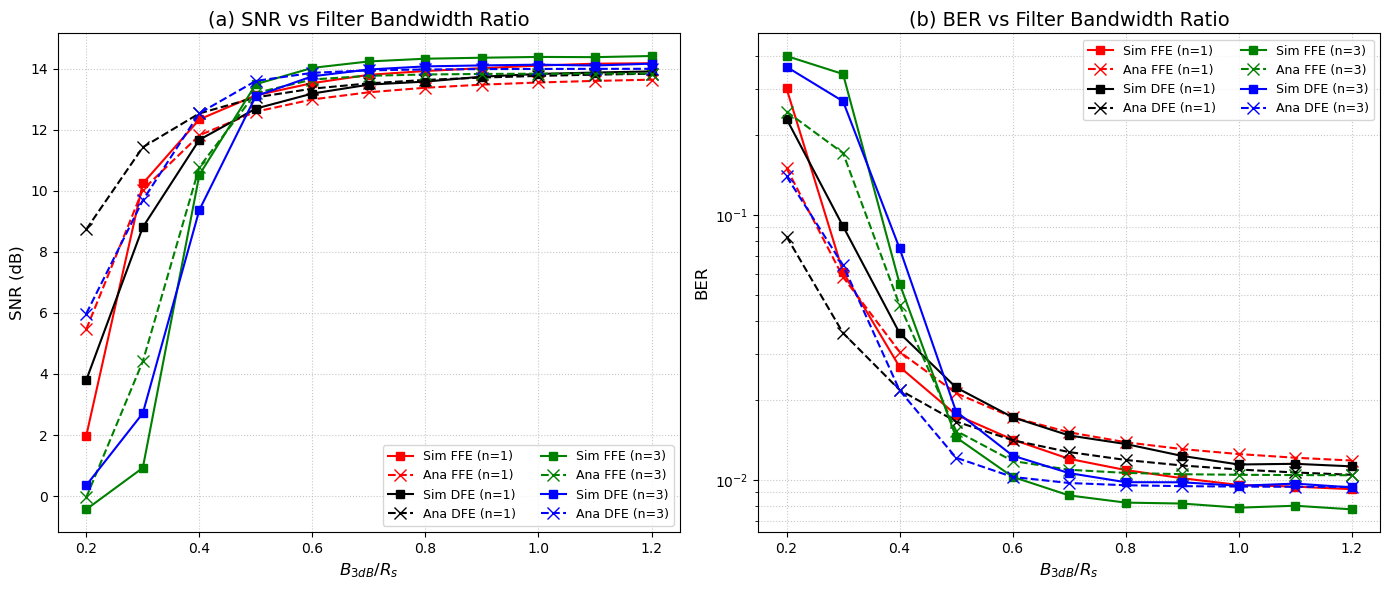

In [4]:
# 3. PLOTAGEM CONFORME FIGURA 2 DO ARTIGO
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Configurações Visuais Estritas ---
# n=1: FFE(red), DFE(black)
# n=3: FFE(green), DFE(blue)
# Simulação: linha sólida + quadrados ('-s')
# Analítico: linha tracejada + cruzes ('--x')

styles = {
    1: {'ffe_c': 'red', 'dfe_c': 'black'},
    3: {'ffe_c': 'green', 'dfe_c': 'blue'}
}

# --- Plot (a): SNR vs B_3dB/Rs ---
for n in n_orders:
    c_ffe = styles[n]['ffe_c']
    c_dfe = styles[n]['dfe_c']
    
    # FFE Sim e Ana
    ax1.plot(B_ratio_range, results[n]['SNR_FFE_sim'], linestyle='-', marker='s', color=c_ffe, 
             label=f'Sim FFE (n={n})', markersize=6)
    ax1.plot(B_ratio_range, results[n]['SNR_FFE_ana'], linestyle='--', marker='x', color=c_ffe, 
             label=f'Ana FFE (n={n})', markersize=8)
    
    # DFE Sim e Ana
    ax1.plot(B_ratio_range, results[n]['SNR_DFE_sim'], linestyle='-', marker='s', color=c_dfe, 
             label=f'Sim DFE (n={n})', markersize=6)
    ax1.plot(B_ratio_range, results[n]['SNR_DFE_ana'], linestyle='--', marker='x', color=c_dfe, 
             label=f'Ana DFE (n={n})', markersize=8)

ax1.set_xlabel('$B_{3dB} / R_s$', fontsize=12)
ax1.set_ylabel('SNR (dB)', fontsize=12)
ax1.set_title('(a) SNR vs Filter Bandwidth Ratio', fontsize=14)
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.legend(loc='lower right', fontsize=9, ncol=2)

# --- Plot (b): BER vs B_3dB/Rs ---
for n in n_orders:
    c_ffe = styles[n]['ffe_c']
    c_dfe = styles[n]['dfe_c']
    
    # FFE Sim e Ana
    ax2.plot(B_ratio_range, results[n]['BER_FFE_sim'], linestyle='-', marker='s', color=c_ffe, 
             label=f'Sim FFE (n={n})', markersize=6)
    ax2.plot(B_ratio_range, results[n]['BER_FFE_ana'], linestyle='--', marker='x', color=c_ffe, 
             label=f'Ana FFE (n={n})', markersize=8)
    
    # DFE Sim e Ana
    ax2.plot(B_ratio_range, results[n]['BER_DFE_sim'], linestyle='-', marker='s', color=c_dfe, 
             label=f'Sim DFE (n={n})', markersize=6)
    ax2.plot(B_ratio_range, results[n]['BER_DFE_ana'], linestyle='--', marker='x', color=c_dfe, 
             label=f'Ana DFE (n={n})', markersize=8)

ax2.set_yscale('log')
# Definir limites de BER razoáveis, por exemplo, de 10^-6 a 10^-1
#ax2.set_ylim(1e-6, 1e-1)
ax2.set_xlabel('$B_{3dB} / R_s$', fontsize=12)
ax2.set_ylabel('BER', fontsize=12)
ax2.set_title('(b) BER vs Filter Bandwidth Ratio', fontsize=14)
ax2.grid(True, which='both', linestyle=':', alpha=0.7)
ax2.legend(loc='upper right', fontsize=9, ncol=2)

plt.tight_layout()
plt.show()

Iniciando varredura da Figura 2: SpS=2, mu=0.

=== Processando ordem do filtro: n = 1 ===
[1/11] B_3dB/Rs = 0.20
[2/11] B_3dB/Rs = 0.30
[3/11] B_3dB/Rs = 0.40
[4/11] B_3dB/Rs = 0.50
[5/11] B_3dB/Rs = 0.60
[6/11] B_3dB/Rs = 0.70
[7/11] B_3dB/Rs = 0.80
[8/11] B_3dB/Rs = 0.90
[9/11] B_3dB/Rs = 1.00
[10/11] B_3dB/Rs = 1.10
[11/11] B_3dB/Rs = 1.20

=== Processando ordem do filtro: n = 3 ===
[1/11] B_3dB/Rs = 0.20
[2/11] B_3dB/Rs = 0.30
[3/11] B_3dB/Rs = 0.40
[4/11] B_3dB/Rs = 0.50
[5/11] B_3dB/Rs = 0.60
[6/11] B_3dB/Rs = 0.70
[7/11] B_3dB/Rs = 0.80
[8/11] B_3dB/Rs = 0.90
[9/11] B_3dB/Rs = 1.00
[10/11] B_3dB/Rs = 1.10
[11/11] B_3dB/Rs = 1.20

================ TEMPOS DE EXECUÇÃO ================
Tempo médio do modelo analítico por ponto: 0.002503727 s
Tempo médio da simulação por ponto:       1.298843132 s
Tempo total da execução:                  28.638 s


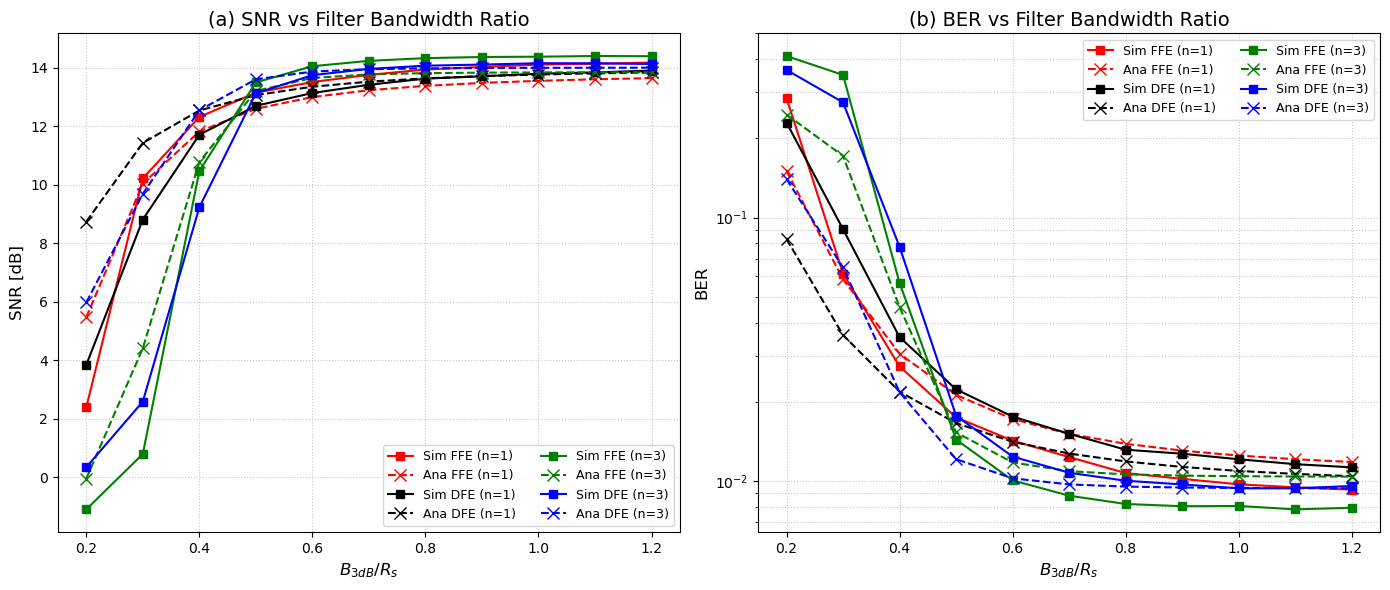

In [5]:
Rs = 56e9
P_avg_alvo = 1.0
pTx_W = P_avg_alvo * 1e-3

M = 4
N0 = 2e-19
RIN = -140
er_db = 6.0
dl = 0.0

SpS = 2
sim_Fs = Rs * SpS
TX_Ts = 1 / Rs

SIM_N = 10_000

B_ratio_range = np.linspace(0.2, 1.2, 11)
n_orders = [1, 3]


# ==========================================================
# Estruturas de resultados
# ==========================================================

results = {
    1: {
        "SNR_FFE_ana": [],
        "SNR_FFE_sim": [],
        "SNR_DFE_ana": [],
        "SNR_DFE_sim": [],
        "BER_FFE_ana": [],
        "BER_FFE_sim": [],
        "BER_DFE_ana": [],
        "BER_DFE_sim": []
    },
    3: {
        "SNR_FFE_ana": [],
        "SNR_FFE_sim": [],
        "SNR_DFE_ana": [],
        "SNR_DFE_sim": [],
        "BER_FFE_ana": [],
        "BER_FFE_sim": [],
        "BER_DFE_ana": [],
        "BER_DFE_sim": []
    }
}


# ==========================================================
# Eixos de frequência do modelo analítico
# ==========================================================

SIM_fmax = 3e12

f_analytical = np.linspace(-SIM_fmax, SIM_fmax, SIM_N + 1)
f_int = np.linspace(-1 / (2 * TX_Ts), 1 / (2 * TX_Ts), SIM_N)

Tb = 1 / (2 * Rs)
Pulse_f = np.sinc(2 * Tb * f_analytical)

band_mask = (f_analytical >= -sim_Fs / 2) & (f_analytical <= sim_Fs / 2)
f_band_sim = f_analytical[band_mask]


# ==========================================================
# Constantes do sinal e dos ruídos
# ==========================================================

ER_lin = 10**(er_db / 10)
x = (ER_lin - 1) / (ER_lin + 1)

OMA_outer = calculate_oma_outer(pTx_W, er_db)
Ps2 = calculate_ps2(pTx_W, M, OMA_outer)

S_RIN_global = calc_S_RIN(Ps2, RIN, f_analytical)
S_th_array = calc_S_th(N0, f_analytical)
S_shot_array = calc_S_shot(pTx_W, 1.0, 1.0, 1.0, f_analytical)

var_th_psd = np.trapezoid(S_th_array[band_mask], x=f_band_sim)
var_shot_psd = np.trapezoid(S_shot_array[band_mask], x=f_band_sim)
var_rin_formula = (10**(RIN / 10) / 2) * sim_Fs


# ==========================================================
# Estruturas para medição dos tempos
# ==========================================================

analytical_execution_times = []
simulation_execution_times = []

total_start_time = time.perf_counter()

print(f"Iniciando varredura da Figura 2: SpS={SpS}, mu=0.")


# ==========================================================
# Loop principal
# ==========================================================

for n_order in n_orders:

    print(f"\n=== Processando ordem do filtro: n = {n_order} ===")

    for i, b_ratio in enumerate(B_ratio_range):

        B_3dB = b_ratio * Rs

        print(f"[{i + 1}/{len(B_ratio_range)}] B_3dB/Rs = {b_ratio:.2f}")

        # ==================================================
        # Modelo analítico
        # ==================================================

        analytical_start_time = time.perf_counter()

        H_ch_total_ana = superGauss(f_analytical, n=n_order, B_3dB=B_3dB)
        H_ch_sq_ana = np.abs(H_ch_total_ana)**2

        S_N_total = np.abs(Pulse_f)**2 * calc_S_N(
            S_RIN_global,
            S_shot_array,
            S_th_array,
            0,
            H_ch_sq_ana,
            False
        )

        S_N_f = np.abs(Pulse_f)**2 * get_spectral_snr(
            f_analytical,
            OMA_outer,
            Rs,
            Pulse_f,
            H_ch_total_ana,
            S_N_total
        )

        S_N_f = np.maximum(
            np.nan_to_num(S_N_f, nan=1e-30, posinf=1e-30, neginf=1e-30),
            1e-30
        )

        SNR_folded = SNR_Folding(S_N_f, f_analytical, mu=0, Rs=Rs)
        safe_SNR = np.maximum(np.abs(SNR_folded), 1e-30)

        SNR_f_interp_dB = np.interp(f_int, f_analytical, 10 * np.log10(safe_SNR))
        SNR_f_interp = 10**(SNR_f_interp_dB / 10)

        integral_ffe = np.trapezoid(1 / (SNR_f_interp + 1), x=f_int)
        integral_dfe = np.trapezoid(np.log1p(SNR_f_interp), x=f_int)

        snr_ffe_lin = 1 / (TX_Ts * integral_ffe) - 1
        snr_dfe_lin = np.exp(TX_Ts * integral_dfe) - 1

        snr_ffe_lin = max(float(snr_ffe_lin), np.finfo(float).tiny)
        snr_dfe_lin = max(float(snr_dfe_lin), np.finfo(float).tiny)

        snr_ffe_dB = 10 * np.log10(snr_ffe_lin)
        snr_dfe_dB = 10 * np.log10(snr_dfe_lin)

        ber_ffe_ana = float(snr_to_ber_pam4(snr_ffe_lin))
        ber_dfe_ana = float(snr_to_ber_pam4(snr_dfe_lin))

        results[n_order]["SNR_FFE_ana"].append(snr_ffe_dB)
        results[n_order]["SNR_DFE_ana"].append(snr_dfe_dB)
        results[n_order]["BER_FFE_ana"].append(ber_ffe_ana)
        results[n_order]["BER_DFE_ana"].append(ber_dfe_ana)

        analytical_execution_times.append(time.perf_counter() - analytical_start_time)

        # ==================================================
        # Simulação temporal
        # ==================================================

        simulation_start_time = time.perf_counter()

        paramBits = parameters()
        paramBits.nBits = 1_000_000
        paramBits.mode = "random"

        bits = bitSource(paramBits)

        symb_Tx = modulateGray(bits, M, "pam")
        symb_Tx_up = upsample(symb_Tx, SpS)

        paramPulse = parameters()
        paramPulse.pulseType = "rect"
        paramPulse.SpS = SpS

        pulse = pulseShape(paramPulse)

        signal_Tx_base = firFilter(pulse, symb_Tx_up)
        signal_Tx_norm = signal_Tx_base / np.max(np.abs(signal_Tx_base))

        P_opt_ideal = pTx_W * (1 + x * signal_Tx_norm)

        n_rin = np.random.normal(0.0, np.sqrt(var_rin_formula), len(P_opt_ideal))
        P_opt_com_rin = P_opt_ideal * np.maximum(1 + n_rin, 0.0)

        P_opt_fft = fft(P_opt_com_rin)
        f_sim = fftfreq(len(P_opt_com_rin), d=1 / sim_Fs)

        H_ch_total_sim = superGauss(f_sim, n=n_order, B_3dB=B_3dB)
        P_opt_rx = np.real(ifft(P_opt_fft * H_ch_total_sim))

        I_pd = P_opt_rx

        i_th = np.random.normal(0.0, np.sqrt(var_th_psd), len(I_pd))
        i_shot = np.random.normal(0.0, np.sqrt(var_shot_psd), len(I_pd))

        PD_signalRx = I_pd + i_shot + i_th
        sigRx = firFilter(pulse, PD_signalRx)

        nTrain = 100_000
        discard = nTrain

        paramDFE = parameters()
        paramDFE.nTapsFF = 30
        paramDFE.nTapsFB = 30
        paramDFE.SpS = SpS
        paramDFE.mu = 5e-4
        paramDFE.nTrain = nTrain
        paramDFE.M = M
        paramDFE.trainingMode = "fulltime"

        outDFE, _, _, _ = dfe(sigRx, symb_Tx, paramDFE)
        outDFE = pnorm(outDFE)

        paramFFE = parameters()
        paramFFE.nTaps = 200
        paramFFE.mu = 5e-4
        paramFFE.nTrain = nTrain
        paramFFE.SpS = SpS
        paramFFE.M = M
        paramFFE.trainingMode = "fulltime"

        outFFE, _, _ = ffe(sigRx, symb_Tx, paramFFE)
        outFFE = pnorm(outFFE)

        evaluation_slice = slice(discard, -discard // 10)

        ber_ffe, _, snr_ffe_sim = fastBERcalc(
            outFFE[evaluation_slice],
            symb_Tx[evaluation_slice],
            M,
            "pam"
        )

        ber_dfe, _, snr_dfe_sim = fastBERcalc(
            outDFE[evaluation_slice],
            symb_Tx[evaluation_slice],
            M,
            "pam"
        )

        ber_ffe = float(np.asarray(ber_ffe).reshape(-1)[0])
        ber_dfe = float(np.asarray(ber_dfe).reshape(-1)[0])

        snr_ffe_sim = float(np.asarray(snr_ffe_sim).reshape(-1)[0])
        snr_dfe_sim = float(np.asarray(snr_dfe_sim).reshape(-1)[0])

        results[n_order]["SNR_FFE_sim"].append(snr_ffe_sim)
        results[n_order]["SNR_DFE_sim"].append(snr_dfe_sim)
        results[n_order]["BER_FFE_sim"].append(ber_ffe)
        results[n_order]["BER_DFE_sim"].append(ber_dfe)

        simulation_execution_times.append(time.perf_counter() - simulation_start_time)


# ==========================================================
# Tempos médios de execução
# ==========================================================

total_elapsed_time = time.perf_counter() - total_start_time

mean_analytical_time = np.mean(analytical_execution_times)
mean_simulation_time = np.mean(simulation_execution_times)

print("\n================ TEMPOS DE EXECUÇÃO ================")
print(f"Tempo médio do modelo analítico por ponto: {mean_analytical_time:.9f} s")
print(f"Tempo médio da simulação por ponto:       {mean_simulation_time:.9f} s")
print(f"Tempo total da execução:                  {total_elapsed_time:.3f} s")
print("=====================================================")


# ==========================================================
# Plotagem
# ==========================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

styles = {
    1: {"ffe_c": "red", "dfe_c": "black"},
    3: {"ffe_c": "green", "dfe_c": "blue"}
}


# ==========================================================
# Gráfico de SNR
# ==========================================================

for n in n_orders:

    c_ffe = styles[n]["ffe_c"]
    c_dfe = styles[n]["dfe_c"]

    ax1.plot(
        B_ratio_range,
        results[n]["SNR_FFE_sim"],
        linestyle="-",
        marker="s",
        color=c_ffe,
        markersize=6,
        label=f"Sim FFE (n={n})"
    )

    ax1.plot(
        B_ratio_range,
        results[n]["SNR_FFE_ana"],
        linestyle="--",
        marker="x",
        color=c_ffe,
        markersize=8,
        label=f"Ana FFE (n={n})"
    )

    ax1.plot(
        B_ratio_range,
        results[n]["SNR_DFE_sim"],
        linestyle="-",
        marker="s",
        color=c_dfe,
        markersize=6,
        label=f"Sim DFE (n={n})"
    )

    ax1.plot(
        B_ratio_range,
        results[n]["SNR_DFE_ana"],
        linestyle="--",
        marker="x",
        color=c_dfe,
        markersize=8,
        label=f"Ana DFE (n={n})"
    )

ax1.set_xlabel(r"$B_{3dB}/R_s$", fontsize=12)
ax1.set_ylabel("SNR [dB]", fontsize=12)
ax1.set_title("(a) SNR vs Filter Bandwidth Ratio", fontsize=14)
ax1.grid(True, linestyle=":", alpha=0.7)
ax1.legend(loc="lower right", fontsize=9, ncol=2)


# ==========================================================
# Gráfico de BER
# ==========================================================

for n in n_orders:

    c_ffe = styles[n]["ffe_c"]
    c_dfe = styles[n]["dfe_c"]

    ax2.plot(
        B_ratio_range,
        results[n]["BER_FFE_sim"],
        linestyle="-",
        marker="s",
        color=c_ffe,
        markersize=6,
        label=f"Sim FFE (n={n})"
    )

    ax2.plot(
        B_ratio_range,
        results[n]["BER_FFE_ana"],
        linestyle="--",
        marker="x",
        color=c_ffe,
        markersize=8,
        label=f"Ana FFE (n={n})"
    )

    ax2.plot(
        B_ratio_range,
        results[n]["BER_DFE_sim"],
        linestyle="-",
        marker="s",
        color=c_dfe,
        markersize=6,
        label=f"Sim DFE (n={n})"
    )

    ax2.plot(
        B_ratio_range,
        results[n]["BER_DFE_ana"],
        linestyle="--",
        marker="x",
        color=c_dfe,
        markersize=8,
        label=f"Ana DFE (n={n})"
    )

ax2.set_yscale("log")
ax2.set_xlabel(r"$B_{3dB}/R_s$", fontsize=12)
ax2.set_ylabel("BER", fontsize=12)
ax2.set_title("(b) BER vs Filter Bandwidth Ratio", fontsize=14)
ax2.grid(True, which="both", linestyle=":", alpha=0.7)
ax2.legend(loc="upper right", fontsize=9, ncol=2)

plt.tight_layout()
plt.show()

Iniciando reprodução da Fig. 7.
Rs = 56.0 GBaud
P_TX = 0.0 dBm
B3dB/Rs = 0.25
RIN = -140 dB/Hz
Símbolos = 500000
Treinamento conhecido durante toda a sequência.


DFE taps = 0
FFE taps =  4 | DFE taps = 0 | SNR = 7.8848 dB | BER = 1.160e-01
FFE taps =  5 | DFE taps = 0 | SNR = 8.4718 dB | BER = 9.985e-02
FFE taps =  6 | DFE taps = 0 | SNR = 8.6266 dB | BER = 9.614e-02
FFE taps =  7 | DFE taps = 0 | SNR = 9.1946 dB | BER = 8.314e-02
FFE taps =  8 | DFE taps = 0 | SNR = 9.1989 dB | BER = 8.311e-02
FFE taps = 10 | DFE taps = 0 | SNR = 9.3232 dB | BER = 8.034e-02
FFE taps = 12 | DFE taps = 0 | SNR = 9.4173 dB | BER = 7.837e-02
FFE taps = 14 | DFE taps = 0 | SNR = 9.4241 dB | BER = 7.820e-02
FFE taps = 16 | DFE taps = 0 | SNR = 9.4474 dB | BER = 7.770e-02

DFE taps = 1
FFE taps =  4 | DFE taps = 1 | SNR = 9.6616 dB | BER = 7.367e-02
FFE taps =  5 | DFE taps = 1 | SNR = 10.3029 dB | BER = 6.000e-02
FFE taps =  6 | DFE taps = 1 | SNR = 10.3012 dB | BER = 6.005e-02
FFE taps =  7 | DFE taps = 1

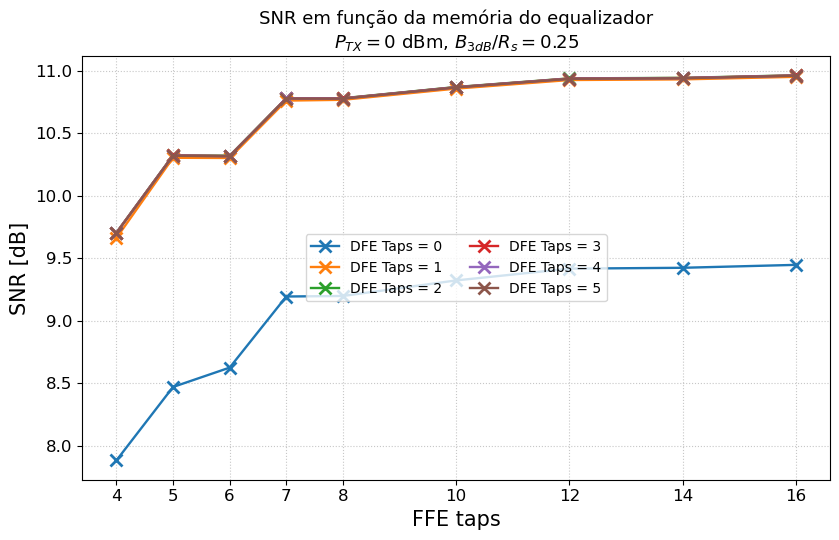

In [9]:
# 2. PARÂMETROS DO ARTIGO

Rs = 56e9
M = 4

bits_per_symbol = int(
    np.log2(M)
)

# Duas amostras por símbolo
SpS = 2
Fs = SpS * Rs

# Potência óptica média transmitida
Ptx_dBm = 0

Ptx_W = (
    10**(Ptx_dBm / 10)
    * 1e-3
)

# Razão de extinção da Tabela I
ER_dB = 6.0

OMA_outer = calculate_oma_outer(
    Ptx_W,
    ER_dB
)

# Coeficiente que relaciona o sinal PAM à potência óptica
ER_linear = 10**(
    ER_dB / 10
)

modulation_index = (
    (ER_linear - 1)
    / (ER_linear + 1)
)

# Receptor PIN
responsivity = 1.0
G = 1.0
F = 1.0

electron_charge = 1.602176634e-19

# Fontes de ruído
N0 = 2e-19
RIN_dB_Hz = -140

RIN_linear = 10**(
    RIN_dB_Hz / 10
)

# Canal da Fig. 7
B3dB_Rs_ratio = 0.25

B_3dB = (
    B3dB_Rs_ratio * Rs
)

supergaussian_order = 1

# Quantidade de dados
nBits = 1_000_000

seed_bits = 1234
seed_rin = 5000
seed_shot = 5001
seed_thermal = 5002

# Parâmetros de adaptação
mu = 5e-4
preconvIters = 3

# Descarte apenas para remover transitórios e bordas.
# Como toda a sequência será usada no treinamento, não descartamos
# nTrain símbolos.
base_guard = 1000


# 
# 3. TAPS MOSTRADOS NA FIGURA
# 

ffe_taps_values = np.array(
    [
        4,
        5,
        6,
        7,
        8,
        10,
        12,
        14,
        16
    ],
    dtype=int
)

dfe_taps_values = [
    0,
    1,
    2,
    3,
    4,
    5
]


# 
# 4. GERAÇÃO DOS BITS E DOS SÍMBOLOS PAM-4
# 

paramBits = parameters()

paramBits.nBits = nBits
paramBits.mode = "random"
paramBits.seed = seed_bits

bitsTx = bitSource(
    paramBits
)

bitsTx = np.asarray(
    bitsTx,
    dtype=np.int64
).reshape(-1)

# Garante número inteiro de símbolos
nBitsValid = (
    len(bitsTx) // bits_per_symbol
) * bits_per_symbol

bitsTx = bitsTx[
    :nBitsValid
]

symbolsTx = modulateGray(
    bitsTx,
    M,
    "pam"
)

symbolsTx = np.real(
    np.asarray(symbolsTx)
).reshape(-1)

# Normalização da potência média dos símbolos
symbolsTx = pnorm(
    symbolsTx
)

symbolsTx = np.real(
    np.asarray(symbolsTx)
).reshape(-1)

nSymbols = len(
    symbolsTx
)


# 
# 5. FORMATAÇÃO DE PULSO
# 

symbolsTx_up = upsample(
    symbolsTx,
    SpS
)

paramPulse = parameters()

paramPulse.pulseType = "rect"
paramPulse.SpS = SpS

pulse = pulseShape(
    paramPulse
)

electricalTx = firFilter(
    pulse,
    symbolsTx_up
)

electricalTx = np.real(
    np.asarray(electricalTx)
).reshape(-1)

electricalTx = (
    electricalTx
    / np.max(
        np.abs(electricalTx)
    )
)


# 
# 6. CONVERSÃO PARA POTÊNCIA ÓPTICA
# 

powerTx = (
    Ptx_W
    * (
        1
        + modulation_index
        * electricalTx
    )
)

# Proteção numérica: potência óptica não pode ser negativa
powerTx = np.maximum(
    powerTx,
    0.0
)

number_samples = len(
    powerTx
)

frequencies = fftfreq(
    number_samples,
    d=1 / Fs
)


# 
# 7. RIN INSTANTÂNEO NA FONTE
#
# sigma_RIN²(t) = RIN_linear * P_TX²(t) * Fs/2
# 

rng_rin = np.random.default_rng(
    seed_rin
)

variance_rin = (
    RIN_linear
    * powerTx**2
    * Fs / 2
)

noise_rin = rng_rin.normal(
    loc=0.0,
    scale=np.sqrt(
        np.maximum(
            variance_rin,
            0.0
        )
    ),
    size=number_samples
)

powerTx_with_rin = (
    powerTx
    + noise_rin
)


# 
# 8. CANAL SUPERGAUSSIANO
# 

H_channel = superGauss(
    f=frequencies,
    n=supergaussian_order,
    B_3dB=B_3dB
)

powerRx = np.real(
    ifft(
        fft(powerTx_with_rin)
        * H_channel
    )
)


# 
# 9. FOTODETECÇÃO E SHOT NOISE
#
# O sinal ainda é representado em potência óptica equivalente.
#
# sigma_shot²(t)
# = (G² F q / R) * P_RX(t) * Fs
# 

power_for_shot = np.maximum(
    powerRx,
    0.0
)

rng_shot = np.random.default_rng(
    seed_shot
)

variance_shot = (
    (G**2 * F * electron_charge / responsivity)
    * power_for_shot
    * Fs
)

noise_shot = rng_shot.normal(
    loc=0.0,
    scale=np.sqrt(
        np.maximum(
            variance_shot,
            0.0
        )
    ),
    size=number_samples
)


# 
# 10. RUÍDO TÉRMICO
#
# sigma_th² = N0 * Fs/2
# 

rng_thermal = np.random.default_rng(
    seed_thermal
)

variance_thermal = (
    N0 * Fs / 2
)

noise_thermal = rng_thermal.normal(
    loc=0.0,
    scale=np.sqrt(
        variance_thermal
    ),
    size=number_samples
)


# 
# 11. SINAL RECEBIDO E FILTRO CASADO
# 

receivedPower = (
    powerRx
    + noise_shot
    + noise_thermal
)

# Remove o valor médio óptico e converte de volta para
# unidades proporcionais aos símbolos PAM
receivedPAM = (
    receivedPower - Ptx_W
) / (
    Ptx_W * modulation_index
)

# Filtro casado ao pulso retangular do transmissor
matchedOutput = firFilter(
    pulse,
    receivedPAM
)

matchedOutput = np.real(
    np.asarray(matchedOutput)
).reshape(-1)

# Normalização para estabilizar a adaptação LMS
matchedOutput = pnorm(
    matchedOutput
)

matchedOutput = np.real(
    np.asarray(matchedOutput)
).reshape(-1)


# 
# 12. ESTRUTURAS DE RESULTADO
# 

SNR_results = {
    n_taps_fb: []
    for n_taps_fb in dfe_taps_values
}

BER_results = {
    n_taps_fb: []
    for n_taps_fb in dfe_taps_values
}


# 
# 13. VARREDURA DOS TAPS
# 

print(
    "Iniciando reprodução da Fig. 7."
)

print(
    f"Rs = {Rs / 1e9:.1f} GBaud"
)

print(
    f"P_TX = {Ptx_dBm:.1f} dBm"
)

print(
    f"B3dB/Rs = {B3dB_Rs_ratio:.2f}"
)

print(
    f"RIN = {RIN_dB_Hz} dB/Hz"
)

print(
    f"Símbolos = {nSymbols}"
)

print(
    "Treinamento conhecido durante toda a sequência."
)

print()


for nTapsFB in dfe_taps_values:

    print(
        f"\nDFE taps = {nTapsFB}"
    )

    for nTapsFF in ffe_taps_values:

        # Toda a sequência é usada como treinamento conhecido.
        # Isso aproxima o full-training mode idealizado do artigo.
        nTrain = nSymbols

        # 
        # 13.1 FFE PURO — DFE TAPS = 0
        # 

        if nTapsFB == 0:

            paramEq = parameters()

            paramEq.nTaps = int(
                nTapsFF
            )

            paramEq.mu = mu
            paramEq.SpS = SpS
            paramEq.nTrain = nTrain
            paramEq.prec = np.float32
            paramEq.M = M
            paramEq.constType = "pam"
            paramEq.f = None

            # Conhecemos todos os símbolos de treinamento.
            paramEq.trainingMode = "data-aided"

            paramEq.preconvIters = preconvIters

            ffe_result = ffe(
                matchedOutput,
                symbolsTx,
                paramEq
            )

            equalizedOutput = ffe_result[0]


        # 
        # 13.2 DFE — DFE TAPS > 0
        # 

        else:

            paramEq = parameters()

            paramEq.nTapsFF = int(
                nTapsFF
            )

            paramEq.nTapsFB = int(
                nTapsFB
            )

            paramEq.mu = mu
            paramEq.SpS = SpS
            paramEq.nTrain = nTrain
            paramEq.prec = np.float32
            paramEq.M = M
            paramEq.constType = "pam"
            paramEq.f = None
            paramEq.b = None

            # Toda a sequência usa a referência conhecida.
            paramEq.trainingMode = "data-aided"

            paramEq.preconvIters = preconvIters

            dfe_result = dfe(
                matchedOutput,
                symbolsTx,
                paramEq
            )

            # Compatível com versões que retornam três ou quatro objetos.
            equalizedOutput = dfe_result[0]


        # 
        # 13.3 CÁLCULO DA SNR
        # 

        guardSymbols = max(
            base_guard,
            int(nTapsFF),
            int(nTapsFB)
        )

        BER_point, SER_point, SNR_point = (
            evaluate_equalizer_output(
                equalized_signal=equalizedOutput,
                reference_symbols=symbolsTx,
                guard_symbols=guardSymbols,
                M=M
            )
        )

        SNR_results[nTapsFB].append(
            SNR_point
        )

        BER_results[nTapsFB].append(
            BER_point
        )

        print(
            f"FFE taps = {nTapsFF:2d} | "
            f"DFE taps = {nTapsFB:1d} | "
            f"SNR = {SNR_point:.4f} dB | "
            f"BER = {BER_point:.3e}"
        )


print(
    "\nVarredura concluída."
)


# 
# 14. GRÁFICO
# 

plt.figure(
    figsize=(8.5, 5.5)
)

for nTapsFB in dfe_taps_values:

    plt.plot(
        ffe_taps_values,
        SNR_results[nTapsFB],
        marker="x",
        linewidth=1.7,
        markersize=8,
        markeredgewidth=2,
        label=f"DFE Taps = {nTapsFB}"
    )

plt.xlabel(
    "FFE taps",
    fontsize=15
)

plt.ylabel(
    "SNR [dB]",
    fontsize=15
)

plt.title(
    (
        "SNR em função da memória do equalizador\n"
        rf"$P_{{TX}}={Ptx_dBm:.0f}$ dBm, "
        rf"$B_{{3dB}}/R_s={B3dB_Rs_ratio:.2f}$"
    ),
    fontsize=13
)

plt.xticks(
    ffe_taps_values
)

plt.grid(
    True,
    linestyle=":",
    alpha=0.7
)

plt.legend(
    ncol=2,
    fontsize=10,
    loc="center"
)

plt.tick_params(
    axis="both",
    labelsize=12
)

plt.tight_layout()
plt.show()

Iniciando reprodução da Fig. 7.
Rs = 56.0 GBaud
P_TX = 0.0 dBm
B3dB/Rs = 0.25
RIN = -140 dB/Hz
Símbolos = 500000
Treinamento conhecido durante toda a sequência.


DFE taps = 0
FFE taps =  4 | DFE taps = 0 | SNR = 7.8848 dB | BER = 1.160e-01
FFE taps =  5 | DFE taps = 0 | SNR = 8.4718 dB | BER = 9.985e-02
FFE taps =  6 | DFE taps = 0 | SNR = 8.6266 dB | BER = 9.614e-02
FFE taps =  7 | DFE taps = 0 | SNR = 9.1946 dB | BER = 8.314e-02
FFE taps =  8 | DFE taps = 0 | SNR = 9.1989 dB | BER = 8.311e-02
FFE taps = 10 | DFE taps = 0 | SNR = 9.3232 dB | BER = 8.034e-02
FFE taps = 12 | DFE taps = 0 | SNR = 9.4173 dB | BER = 7.837e-02
FFE taps = 14 | DFE taps = 0 | SNR = 9.4241 dB | BER = 7.820e-02
FFE taps = 16 | DFE taps = 0 | SNR = 9.4474 dB | BER = 7.770e-02

DFE taps = 1
FFE taps =  4 | DFE taps = 1 | SNR = 9.6616 dB | BER = 7.367e-02
FFE taps =  5 | DFE taps = 1 | SNR = 10.3029 dB | BER = 6.000e-02
FFE taps =  6 | DFE taps = 1 | SNR = 10.3012 dB | BER = 6.005e-02
FFE taps =  7 | DFE taps = 1

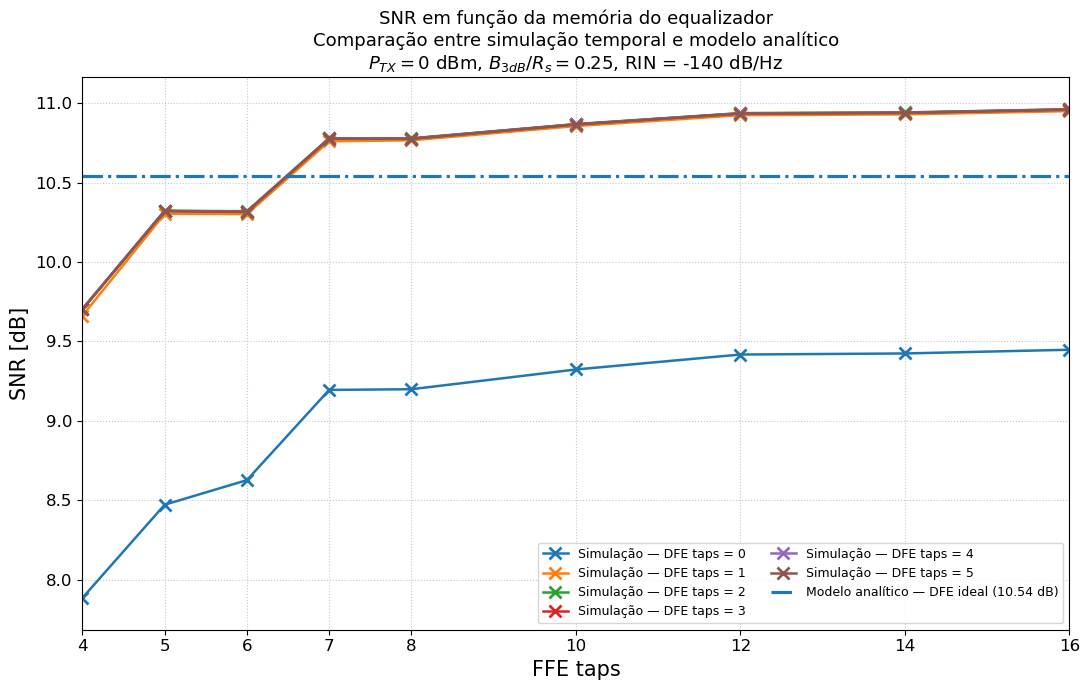

In [ ]:
Rs = 56e9
M = 4
bits_per_symbol = int(np.log2(M))

# Duas amostras por símbolo
SpS = 2
Fs = SpS * Rs

# Potência óptica média transmitida
Ptx_dBm = 0
Ptx_W = 10**(Ptx_dBm / 10) * 1e-3

# Razão de extinção da Tabela I
ER_dB = 6.0
OMA_outer = calculate_oma_outer(Ptx_W, ER_dB)

# Coeficiente que relaciona o sinal PAM à potência óptica
ER_linear = 10**(ER_dB / 10)
modulation_index = (ER_linear - 1) / (ER_linear + 1)

# Receptor PIN
responsivity = 1.0
G = 1.0
F = 1.0
electron_charge = 1.602176634e-19

# Fontes de ruído
N0 = 2e-19
RIN_dB_Hz = -140
RIN_linear = 10**(RIN_dB_Hz / 10)

# Canal da Fig. 7
B3dB_Rs_ratio = 0.25
B_3dB = B3dB_Rs_ratio * Rs
supergaussian_order = 1

# Quantidade de dados
nBits = 1_000_000

seed_bits = 1234
seed_rin = 5000
seed_shot = 5001
seed_thermal = 5002

# Parâmetros de adaptação
mu = 5e-4
preconvIters = 3

# Descarte apenas para remover transitórios e bordas.
# Como toda a sequência será usada no treinamento, não descartamos nTrain símbolos.
base_guard = 1000


 
# 3. TAPS MOSTRADOS NA FIGURA


ffe_taps_values = np.array([4, 5, 6, 7, 8, 10, 12, 14, 16], dtype=int)
dfe_taps_values = [0, 1, 2, 3, 4, 5]


# 4. GERAÇÃO DOS BITS E DOS SÍMBOLOS PAM-4

paramBits = parameters()
paramBits.nBits = nBits
paramBits.mode = "random"
paramBits.seed = seed_bits

bitsTx = bitSource(paramBits)
bitsTx = np.asarray(bitsTx, dtype=np.int64).reshape(-1)

# Garante número inteiro de símbolos
nBitsValid = (len(bitsTx) // bits_per_symbol) * bits_per_symbol
bitsTx = bitsTx[:nBitsValid]

symbolsTx = modulateGray(bitsTx, M, "pam")
symbolsTx = np.real(np.asarray(symbolsTx)).reshape(-1)

# Normalização da potência média dos símbolos
symbolsTx = pnorm(symbolsTx)
symbolsTx = np.real(np.asarray(symbolsTx)).reshape(-1)

nSymbols = len(symbolsTx)


# 5. FORMATAÇÃO DE PULSO

symbolsTx_up = upsample(symbolsTx, SpS)

paramPulse = parameters()
paramPulse.pulseType = "rect"
paramPulse.SpS = SpS

pulse = pulseShape(paramPulse)

electricalTx = firFilter(pulse, symbolsTx_up)
electricalTx = np.real(np.asarray(electricalTx)).reshape(-1)
electricalTx = electricalTx / np.max(np.abs(electricalTx))



# 6. CONVERSÃO PARA POTÊNCIA ÓPTICA


powerTx = Ptx_W * (1 + modulation_index * electricalTx)

# Proteção numérica: potência óptica não pode ser negativa
powerTx = np.maximum(powerTx, 0.0)

number_samples = len(powerTx)
frequencies = fftfreq(number_samples, d=1 / Fs)



# 7. RIN INSTANTÂNEO NA FONTE
#
# sigma_RIN²(t) = RIN_linear * P_TX²(t) * Fs/2

rng_rin = np.random.default_rng(seed_rin)

variance_rin = RIN_linear * powerTx**2 * Fs / 2

noise_rin = rng_rin.normal(
    loc=0.0,
    scale=np.sqrt(np.maximum(variance_rin, 0.0)),
    size=number_samples
)

powerTx_with_rin = powerTx + noise_rin



# 8. CANAL SUPERGAUSSIANO


H_channel = superGauss(f=frequencies, n=supergaussian_order, B_3dB=B_3dB)

powerRx = np.real(
    ifft(
        fft(powerTx_with_rin)
        * H_channel
    )
)



# 9. FOTODETECÇÃO E SHOT NOISE
#
# O sinal ainda é representado em potência óptica equivalente.
#
# sigma_shot²(t) = (G² F q / R) * P_RX(t) * Fs

power_for_shot = np.maximum(powerRx, 0.0)
rng_shot = np.random.default_rng(seed_shot)

variance_shot = (G**2 * F * electron_charge / responsivity) * power_for_shot * Fs

noise_shot = rng_shot.normal(
    loc=0.0,
    scale=np.sqrt(np.maximum(variance_shot, 0.0)),
    size=number_samples
)



# 10. RUÍDO TÉRMICO
#
# sigma_th² = N0 * Fs/2


rng_thermal = np.random.default_rng(seed_thermal)
variance_thermal = N0 * Fs / 2

noise_thermal = rng_thermal.normal(
    loc=0.0,
    scale=np.sqrt(variance_thermal),
    size=number_samples
)



# 11. SINAL RECEBIDO E FILTRO CASADO


receivedPower = powerRx + noise_shot + noise_thermal

# Remove o valor médio óptico e converte de volta para
# unidades proporcionais aos símbolos PAM
receivedPAM = (receivedPower - Ptx_W) / (Ptx_W * modulation_index)

# Filtro casado ao pulso retangular do transmissor
matchedOutput = firFilter(pulse, receivedPAM)
matchedOutput = np.real(np.asarray(matchedOutput)).reshape(-1)

# Normalização para estabilizar a adaptação LMS
matchedOutput = pnorm(matchedOutput)
matchedOutput = np.real(np.asarray(matchedOutput)).reshape(-1)



# 12. ESTRUTURAS DE RESULTADO


SNR_results = {n_taps_fb: [] for n_taps_fb in dfe_taps_values}
BER_results = {n_taps_fb: [] for n_taps_fb in dfe_taps_values}



# 13. VARREDURA DOS TAPS


print("Iniciando reprodução da Fig. 7.")
print(f"Rs = {Rs / 1e9:.1f} GBaud")
print(f"P_TX = {Ptx_dBm:.1f} dBm")
print(f"B3dB/Rs = {B3dB_Rs_ratio:.2f}")
print(f"RIN = {RIN_dB_Hz} dB/Hz")
print(f"Símbolos = {nSymbols}")
print("Treinamento conhecido durante toda a sequência.")
print()

for nTapsFB in dfe_taps_values:
    print(f"\nDFE taps = {nTapsFB}")

    for nTapsFF in ffe_taps_values:
        # Toda a sequência é usada como treinamento conhecido.
        # Isso aproxima o full-training mode idealizado do artigo.
        nTrain = nSymbols

        # --------------------------------------------------
        # 13.1 FFE PURO — DFE TAPS = 0
        # --------------------------------------------------

        if nTapsFB == 0:
            paramEq = parameters()
            paramEq.nTaps = int(nTapsFF)
            paramEq.mu = mu
            paramEq.SpS = SpS
            paramEq.nTrain = nTrain
            paramEq.prec = np.float32
            paramEq.M = M
            paramEq.constType = "pam"
            paramEq.f = None

            # Conhecemos todos os símbolos de treinamento.
            paramEq.trainingMode = "data-aided"
            paramEq.preconvIters = preconvIters

            ffe_result = ffe(matchedOutput, symbolsTx, paramEq)
            equalizedOutput = ffe_result[0]

        
        # 13.2 DFE — DFE TAPS > 0
        

        else:
            paramEq = parameters()
            paramEq.nTapsFF = int(nTapsFF)
            paramEq.nTapsFB = int(nTapsFB)
            paramEq.mu = mu
            paramEq.SpS = SpS
            paramEq.nTrain = nTrain
            paramEq.prec = np.float32
            paramEq.M = M
            paramEq.constType = "pam"
            paramEq.f = None
            paramEq.b = None

            # Toda a sequência usa a referência conhecida.
            paramEq.trainingMode = "data-aided"
            paramEq.preconvIters = preconvIters

            dfe_result = dfe(matchedOutput, symbolsTx, paramEq)

            # Compatível com versões que retornam três ou quatro objetos.
            equalizedOutput = dfe_result[0]

        # 13.3 CÁLCULO DA SNR
        

        guardSymbols = max(base_guard, int(nTapsFF), int(nTapsFB))

        BER_point, SER_point, SNR_point = evaluate_equalizer_output(
            equalized_signal=equalizedOutput,
            reference_symbols=symbolsTx,
            guard_symbols=guardSymbols,
            M=M
        )

        SNR_results[nTapsFB].append(SNR_point)
        BER_results[nTapsFB].append(BER_point)

        print(
            f"FFE taps = {nTapsFF:2d} | "
            f"DFE taps = {nTapsFB:1d} | "
            f"SNR = {SNR_point:.4f} dB | "
            f"BER = {BER_point:.3e}"
        )

print("\nVarredura concluída.")


# Eixos de frequência


SIM_N_ANALYTICAL = 20_000
SIM_FMAX_ANALYTICAL = 3e12

f_analytical = np.linspace(-SIM_FMAX_ANALYTICAL, SIM_FMAX_ANALYTICAL, SIM_N_ANALYTICAL + 1)

T_symbol = 1 / Rs
T_bit = T_symbol / np.log2(M)

f_nyquist = np.linspace(-Rs / 2, Rs / 2, SIM_N_ANALYTICAL)



# Pulso do transmissor e canal

Pulse_f = np.sinc(2 * T_bit * f_analytical)

H_channel_analytical = superGauss(f_analytical, supergaussian_order, B_3dB)
H_channel_power = np.abs(H_channel_analytical)**2


# Níveis ópticos e fontes de ruído

power_levels = calculate_ps2(Ptx_W, M, OMA_outer)

S_RIN_analytical = calc_S_RIN(power_levels, RIN_dB_Hz, f_analytical)
S_shot_analytical = calc_S_shot(Ptx_W, G, F, responsivity, f_analytical)
S_thermal_analytical = calc_S_th(N0, f_analytical)
S_ADC_analytical = np.zeros_like(f_analytical)

S_noise_analytical = calc_S_N(S_RIN_analytical,S_shot_analytical, S_thermal_analytical, S_ADC_analytical, H_channel_power, False)

# SNR espectral 

SNR_spectral = get_spectral_snr(f_analytical, OMA_outer, Rs, Pulse_f, H_channel_analytical, S_noise_analytical )

SNR_spectral = np.nan_to_num(SNR_spectral, nan=0.0, posinf=0.0, neginf=0.0)
SNR_spectral = np.maximum(np.real(SNR_spectral), 1e-300)



# Folding espectral


SNR_folded = SNR_Folding(SNR_spectral, f_analytical, mu=2, Rs=Rs)
SNR_folded = np.maximum(np.real(SNR_folded), 1e-300)



# Interpolação na banda de Nyquist
 

SNR_folded_dB = 10 * np.log10(SNR_folded)
SNR_nyquist_dB = np.interp(f_nyquist, f_analytical, SNR_folded_dB)
SNR_nyquist_linear = 10**(SNR_nyquist_dB / 10)


# SNR do FFE MMSE ideal

integrand_FFE = 1 / (1 + SNR_nyquist_linear)
integral_FFE = np.trapezoid(integrand_FFE, x=f_nyquist)

SNR_FFE_analytical_linear = 1 / (T_symbol * integral_FFE) - 1
SNR_FFE_analytical_linear = max(float(SNR_FFE_analytical_linear), 0.0)

if SNR_FFE_analytical_linear > 0:
    SNR_FFE_analytical_dB = 10 * np.log10(SNR_FFE_analytical_linear)
else:
    SNR_FFE_analytical_dB = -np.inf



# SNR do DFE MMSE ideal


integrand_DFE = np.log1p(SNR_nyquist_linear)
integral_DFE = np.trapezoid(integrand_DFE, x=f_nyquist)

SNR_DFE_analytical_linear = np.exp(T_symbol * integral_DFE) - 1
SNR_DFE_analytical_linear = max(float(SNR_DFE_analytical_linear), 0.0)

if SNR_DFE_analytical_linear > 0:
    SNR_DFE_analytical_dB = 10 * np.log10(SNR_DFE_analytical_linear)
else:
    SNR_DFE_analytical_dB = -np.inf


# Resultados analíticos


print("Resultados analíticos para a condição da Fig. 7:")
print(f"SNR FFE ideal = {SNR_FFE_analytical_dB:.4f} dB")
print(f"SNR DFE ideal = {SNR_DFE_analytical_dB:.4f} dB")



# Preparação dos limites do gráfico

all_simulated_snr = np.concatenate([
    np.asarray(SNR_results[nTapsFB], dtype=float)
    for nTapsFB in dfe_taps_values
])

all_snr_values = np.concatenate((
    all_simulated_snr,
    np.array([SNR_FFE_analytical_dB, SNR_DFE_analytical_dB])
))

finite_snr_values = all_snr_values[np.isfinite(all_snr_values)]


# Gráfico comparativo

plt.figure(figsize=(11, 7))

for nTapsFB in dfe_taps_values:
    plt.plot(
        ffe_taps_values,
        SNR_results[nTapsFB],
        marker="x",
        linewidth=1.8,
        markersize=8,
        markeredgewidth=2,
        label=f"Simulação — DFE taps = {nTapsFB}"
    )

# Para mostrar também o limite analítico do FFE.
#
# plt.axhline(
#     SNR_FFE_analytical_dB,
#     linestyle="--",
#     linewidth=2.3,
#     label=f"Modelo analítico — FFE ideal ({SNR_FFE_analytical_dB:.2f} dB)"
# )

plt.axhline(
    SNR_DFE_analytical_dB,
    linestyle="-.",
    linewidth=2.3,
    label=f"Modelo analítico — DFE ideal ({SNR_DFE_analytical_dB:.2f} dB)"
)

plt.xlabel("FFE taps", fontsize=15)
plt.ylabel("SNR [dB]", fontsize=15)

plt.title(
    "SNR em função da memória do equalizador\n"
    "Comparação entre simulação temporal e modelo analítico\n"
    rf"$P_{{TX}}={Ptx_dBm:.0f}$ dBm, "
    rf"$B_{{3dB}}/R_s={B3dB_Rs_ratio:.2f}$, "
    rf"RIN = {RIN_dB_Hz} dB/Hz",
    fontsize=13
)

plt.xticks(ffe_taps_values)
plt.xlim(np.min(ffe_taps_values), np.max(ffe_taps_values))

if len(finite_snr_values) > 0:
    vertical_margin = 0.2
    plt.ylim(np.min(finite_snr_values) - vertical_margin, np.max(finite_snr_values) + vertical_margin)

plt.grid(True, which="both", linestyle=":", alpha=0.7)
plt.legend(ncol=2, fontsize=9, loc="best")
plt.tick_params(axis="both", labelsize=12)

plt.tight_layout()
plt.show()

Iniciando reprodução da Fig. 6.
Rs = 56.0 GBaud
G = 5.0 dB (3.162 linear)
F = 3.0 dB (1.995 linear)
R = 0.7 A/W
N0 corrente = 6.000e-23 A²/Hz


ER = 3.0 dB
ER=3 dB | P_RX=-20.0 dBm | SNR modelo=  8.74 dB | SNR sim=  9.36 dB | shot/th=  0.75
ER=3 dB | P_RX=-19.5 dBm | SNR modelo=  9.48 dB | SNR sim= 10.03 dB | shot/th=  0.84
ER=3 dB | P_RX=-19.0 dBm | SNR modelo= 10.20 dB | SNR sim= 10.66 dB | shot/th=  0.94
ER=3 dB | P_RX=-18.5 dBm | SNR modelo= 10.90 dB | SNR sim= 11.30 dB | shot/th=  1.05
ER=3 dB | P_RX=-18.0 dBm | SNR modelo= 11.59 dB | SNR sim= 11.93 dB | shot/th=  1.18
ER=3 dB | P_RX=-17.5 dBm | SNR modelo= 12.24 dB | SNR sim= 12.52 dB | shot/th=  1.33
ER=3 dB | P_RX=-17.0 dBm | SNR modelo= 12.88 dB | SNR sim= 13.10 dB | shot/th=  1.49
ER=3 dB | P_RX=-16.5 dBm | SNR modelo= 13.50 dB | SNR sim= 13.66 dB | shot/th=  1.67
ER=3 dB | P_RX=-16.0 dBm | SNR modelo= 14.09 dB | SNR sim= 14.18 dB | shot/th=  1.87
ER=3 dB | P_RX=-15.5 dBm | SNR modelo= 14.66 dB | SNR sim= 14.72 dB | shot/th= 

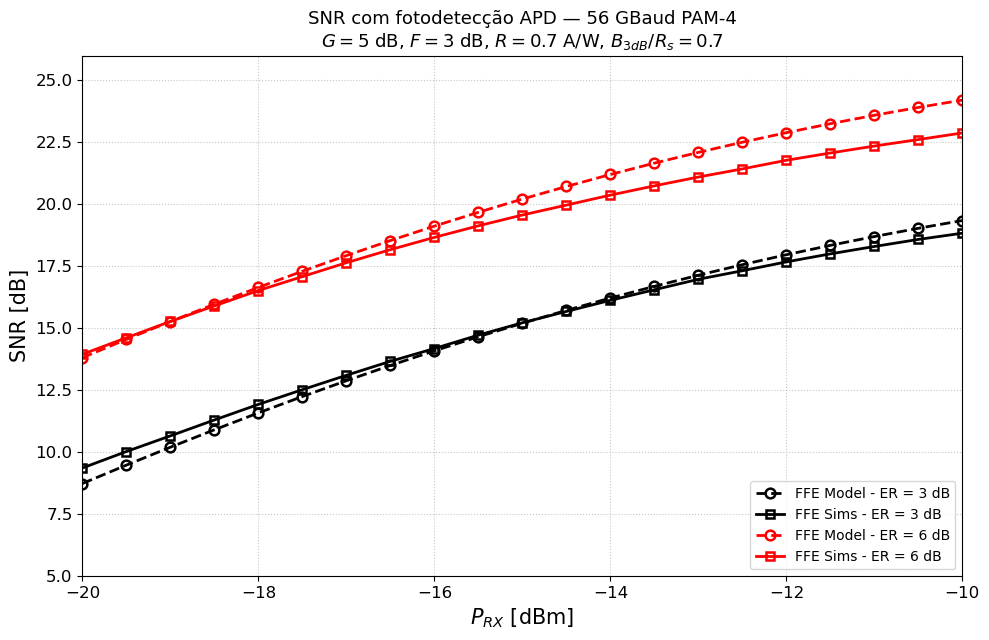

In [7]:
# FIGURA 6 — FOTODETECÇÃO POR AVALANCHE
#
# SNR em função da potência óptica recebida para:
#   - 56 GBaud PAM-4
#   - ER = 3 dB e 6 dB
#   - APD: G = 5 dB, F = 3 dB e R = 0.7 A/W
#   - B3dB/Rs = 0.7
#   - RIN = -140 dB/Hz
#   - FFE de 200 taps

# Funções auxiliares


# Parâmetros do sistema


Rs = 56e9
M = 4
bits_per_symbol = int(np.log2(M))

SpS = 2
Fs = SpS * Rs

P_TX_dBm = 0.0
P_TX_W = 1e-3 * 10**(P_TX_dBm / 10)

P_RX_dBm_values = np.arange(-20.0, -9.5, 0.5)
P_RX_W_values = 1e-3 * 10**(P_RX_dBm_values / 10)

ER_values_dB = [3.0, 6.0]


# Parâmetros do APD

G_dB = 5.0
F_dB = 3.0

G_APD = 10**(G_dB / 10)
F_APD = 10**(F_dB / 10)

responsivity = 0.7
electron_charge = 1.602176634e-19



# Canal e fontes de ruído


B3dB_Rs_ratio = 0.7
B_3dB = B3dB_Rs_ratio * Rs
supergaussian_order = 1

RIN_dB_Hz = -140.0
RIN_linear = 10**(RIN_dB_Hz / 10)

# PSD bilateral equivalente do ruído térmico em A²/Hz
N0_current = 6e-23



# Parâmetros da simulação
#

nBits = 500_000

seed_bits = 1234
seed_rin = 5000
seed_shot = 6000
seed_thermal = 7000

nTapsFFE = 200
mu = 5e-4
preconvIters = 3
base_guard = 1000



# Geração dos símbolos PAM-4

paramBits = parameters()
paramBits.nBits = nBits
paramBits.mode = "random"
paramBits.seed = seed_bits

bitsTx = np.asarray(bitSource(paramBits), dtype=np.int64).reshape(-1)

number_valid_bits = (len(bitsTx) // bits_per_symbol) * bits_per_symbol
bitsTx = bitsTx[:number_valid_bits]

symbolsTx = np.real(np.asarray(modulateGray(bitsTx, M, "pam"))).reshape(-1)
reference_symbols = symbolsTx.copy()

number_symbols = len(reference_symbols)



# Formatação de pulso


symbols_upsampled = upsample(reference_symbols, SpS)

paramPulse = parameters()
paramPulse.pulseType = "rect"
paramPulse.SpS = SpS

pulse = pulseShape(paramPulse)

electricalTx = np.real(np.asarray(firFilter(pulse, symbols_upsampled))).reshape(-1)
electricalTx_normalized = electricalTx / np.max(np.abs(electricalTx))

number_samples = len(electricalTx_normalized)
frequencies_simulation = fftfreq(number_samples, d=1 / Fs)



# Canal da simulação

H_channel_simulation = superGauss(frequencies_simulation, supergaussian_order, B_3dB)


# Grade de frequência do modelo analítico

maximum_frequency = 3e12
number_frequency_points = 120_001

frequencies_analytical = np.linspace(-maximum_frequency, maximum_frequency, number_frequency_points)

symbol_period = 1 / Rs
H_TX_analytical = np.sinc(symbol_period * frequencies_analytical)
H_channel_analytical = superGauss(frequencies_analytical, supergaussian_order, B_3dB)



# Estruturas de resultado

SNR_model = {extinction_ratio: [] for extinction_ratio in ER_values_dB}
SNR_simulation = {extinction_ratio: [] for extinction_ratio in ER_values_dB}

# Varredura da potência recebida


print("Iniciando reprodução da Fig. 6.")
print(f"Rs = {Rs / 1e9:.1f} GBaud")
print(f"G = {G_dB:.1f} dB ({G_APD:.3f} linear)")
print(f"F = {F_dB:.1f} dB ({F_APD:.3f} linear)")
print(f"R = {responsivity:.1f} A/W")
print(f"N0 corrente = {N0_current:.3e} A²/Hz\n")

for ER_dB in ER_values_dB:

    print(f"\nER = {ER_dB:.1f} dB")

    for power_index, (P_RX_dBm, P_RX_W) in enumerate(zip(P_RX_dBm_values, P_RX_W_values)):

     
        # Potência óptica recebida
        

        OMA_RX = calculate_oma_outer(P_RX_W, ER_dB)

        powerRx_ideal = P_RX_W + (OMA_RX / 2) * electricalTx_normalized
        powerRx_ideal = np.maximum(powerRx_ideal, 0.0)

        
        # RIN óptico

        rng_rin = np.random.default_rng(seed_rin + power_index + int(ER_dB * 1000))

        variance_rin_optical = RIN_linear * powerRx_ideal**2 * Fs / 2
        noise_rin_optical = rng_rin.normal(0.0, np.sqrt(np.maximum(variance_rin_optical, 0.0)), number_samples)

        optical_signal_with_rin = powerRx_ideal + noise_rin_optical

        
        # Limitação de banda
        

        optical_filtered = np.real(ifft(fft(optical_signal_with_rin) * H_channel_simulation))

     
        # Fotocorrente útil do APD
        

        photocurrent_signal = G_APD * responsivity * optical_filtered

         
        # Shot noise de avalanche
         

        optical_power_for_shot = np.maximum(optical_filtered, 0.0)

        rng_shot = np.random.default_rng(seed_shot + power_index + int(ER_dB * 1000))

        variance_shot_current = G_APD**2 * F_APD * electron_charge * responsivity * optical_power_for_shot * Fs
        noise_shot_current = rng_shot.normal(0.0, np.sqrt(np.maximum(variance_shot_current, 0.0)), number_samples)

         
        # Ruído térmico
        

        rng_thermal = np.random.default_rng(seed_thermal + power_index + int(ER_dB * 1000))

        variance_thermal_current = N0_current * Fs / 2
        noise_thermal_current = rng_thermal.normal(0.0, np.sqrt(variance_thermal_current), number_samples)

        
        # Entrada do equalizador
        

        received_current = photocurrent_signal + noise_shot_current + noise_thermal_current
        average_photocurrent = G_APD * responsivity * P_RX_W
        received_current_ac = received_current - average_photocurrent

        equalizer_input = np.real(np.asarray(pnorm(received_current_ac))).reshape(-1)

        
        # FFE da OptiCommPy
        

        paramFFE = parameters()
        paramFFE.nTaps = nTapsFFE
        paramFFE.mu = mu
        paramFFE.SpS = SpS
        paramFFE.nTrain = number_symbols
        paramFFE.prec = np.float32
        paramFFE.M = M
        paramFFE.constType = "pam"
        paramFFE.f = None
        paramFFE.trainingMode = "data-aided"
        paramFFE.preconvIters = preconvIters

        equalized_output = ffe(equalizer_input, reference_symbols, paramFFE)[0]

        guard_symbols = max(base_guard, nTapsFFE)
        SNR_simulation_point = calculate_output_snr(equalized_output, reference_symbols, guard_symbols)

        SNR_simulation[ER_dB].append(SNR_simulation_point)

        
        # Modelo analítico no domínio de corrente
        

        signal_current_psd = (
            (G_APD * responsivity)**2
            * (5 / 36)
            * symbol_period
            * OMA_RX**2
            * np.abs(H_TX_analytical)**2
            * np.abs(H_channel_analytical)**2
        )

        power_levels_RX = P_RX_W + np.linspace(-1, 1, M) * OMA_RX / 2
        mean_square_power_RX = np.mean(power_levels_RX**2)

        S_RIN_current = (
            (G_APD * responsivity)**2
            * RIN_linear
            * mean_square_power_RX
            / 2
            * np.abs(H_channel_analytical)**2
        )

        S_shot_current = G_APD**2 * F_APD * electron_charge * responsivity * P_RX_W
        S_thermal_current = N0_current / 2

        total_current_noise_psd = S_RIN_current + S_shot_current + S_thermal_current

        spectral_snr = signal_current_psd / np.maximum(total_current_noise_psd, np.finfo(float).tiny)
        spectral_snr = np.nan_to_num(spectral_snr, nan=0.0, posinf=0.0, neginf=0.0)

        spectral_snr_folded = fold_spectral_snr(spectral_snr, frequencies_analytical, Rs, number_of_folds=4)
        SNR_model_point = analytical_ffe_snr(frequencies_analytical, spectral_snr_folded, Rs)

        SNR_model[ER_dB].append(SNR_model_point)

        
        # Diagnóstico
        

        average_shot_variance = G_APD**2 * F_APD * electron_charge * responsivity * P_RX_W * Fs
        shot_thermal_ratio = average_shot_variance / variance_thermal_current

        print(
            f"ER={ER_dB:.0f} dB | "
            f"P_RX={P_RX_dBm:5.1f} dBm | "
            f"SNR modelo={SNR_model_point:6.2f} dB | "
            f"SNR sim={SNR_simulation_point:6.2f} dB | "
            f"shot/th={shot_thermal_ratio:6.2f}"
        )

print("\nVarredura concluída.")



# Gráfico

plt.figure(figsize=(10, 6.5))

plt.plot(
    P_RX_dBm_values,
    SNR_model[3.0],
    linestyle="--",
    marker="o",
    linewidth=2,
    markersize=7,
    markerfacecolor="none",
    markeredgewidth=1.8,
    color="black",
    label="FFE Model - ER = 3 dB"
)

plt.plot(
    P_RX_dBm_values,
    SNR_simulation[3.0],
    linestyle="-",
    marker="s",
    linewidth=2,
    markersize=6,
    markerfacecolor="none",
    markeredgewidth=1.8,
    color="black",
    label="FFE Sims - ER = 3 dB"
)

plt.plot(
    P_RX_dBm_values,
    SNR_model[6.0],
    linestyle="--",
    marker="o",
    linewidth=2,
    markersize=7,
    markerfacecolor="none",
    markeredgewidth=1.8,
    color="red",
    label="FFE Model - ER = 6 dB"
)

plt.plot(
    P_RX_dBm_values,
    SNR_simulation[6.0],
    linestyle="-",
    marker="s",
    linewidth=2,
    markersize=6,
    markerfacecolor="none",
    markeredgewidth=1.8,
    color="red",
    label="FFE Sims - ER = 6 dB"
)

plt.xlabel(r"$P_{RX}$ [dBm]", fontsize=15)
plt.ylabel("SNR [dB]", fontsize=15)

plt.title(
    "SNR com fotodetecção APD — 56 GBaud PAM-4\n"
    rf"$G={G_dB:.0f}$ dB, "
    rf"$F={F_dB:.0f}$ dB, "
    rf"$R={responsivity:.1f}$ A/W, "
    rf"$B_{{3dB}}/R_s={B3dB_Rs_ratio:.1f}$",
    fontsize=13
)

plt.xlim(-20, -10)
plt.ylim(5, 26)
plt.xticks(np.arange(-20, -9, 2))

plt.grid(True, linestyle=":", alpha=0.7)
plt.legend(fontsize=10, loc="lower right")
plt.tick_params(axis="both", labelsize=12)

plt.tight_layout()
plt.show()

Calculando o modelo analítico...
Iniciando as simulações temporais.
Símbolos: 250000
Taps do FFE: 200


ER = 3 dB | L = 0 km
P_RX = -23.0 dBm | SNR modelo =   2.73 dB | SNR sim =   4.61 dB | BER modelo = 2.025e-01 | BER sim = 2.174e-01
P_RX = -22.0 dBm | SNR modelo =   4.49 dB | SNR sim =   5.89 dB | BER modelo = 1.698e-01 | BER sim = 1.753e-01
P_RX = -21.0 dBm | SNR modelo =   6.21 dB | SNR sim =   7.23 dB | BER modelo = 1.350e-01 | BER sim = 1.364e-01
P_RX = -20.0 dBm | SNR modelo =   7.88 dB | SNR sim =   8.61 dB | BER modelo = 1.003e-01 | BER sim = 1.002e-01
P_RX = -19.0 dBm | SNR modelo =   9.48 dB | SNR sim =  10.03 dB | BER modelo = 6.845e-02 | BER sim = 6.713e-02
P_RX = -18.0 dBm | SNR modelo =  11.00 dB | SNR sim =  11.39 dB | BER modelo = 4.207e-02 | BER sim = 4.170e-02
P_RX = -17.0 dBm | SNR modelo =  12.44 dB | SNR sim =  12.71 dB | BER modelo = 2.289e-02 | BER sim = 2.274e-02
P_RX = -16.0 dBm | SNR modelo =  13.79 dB | SNR sim =  13.93 dB | BER modelo = 1.091e-02 | BER sim

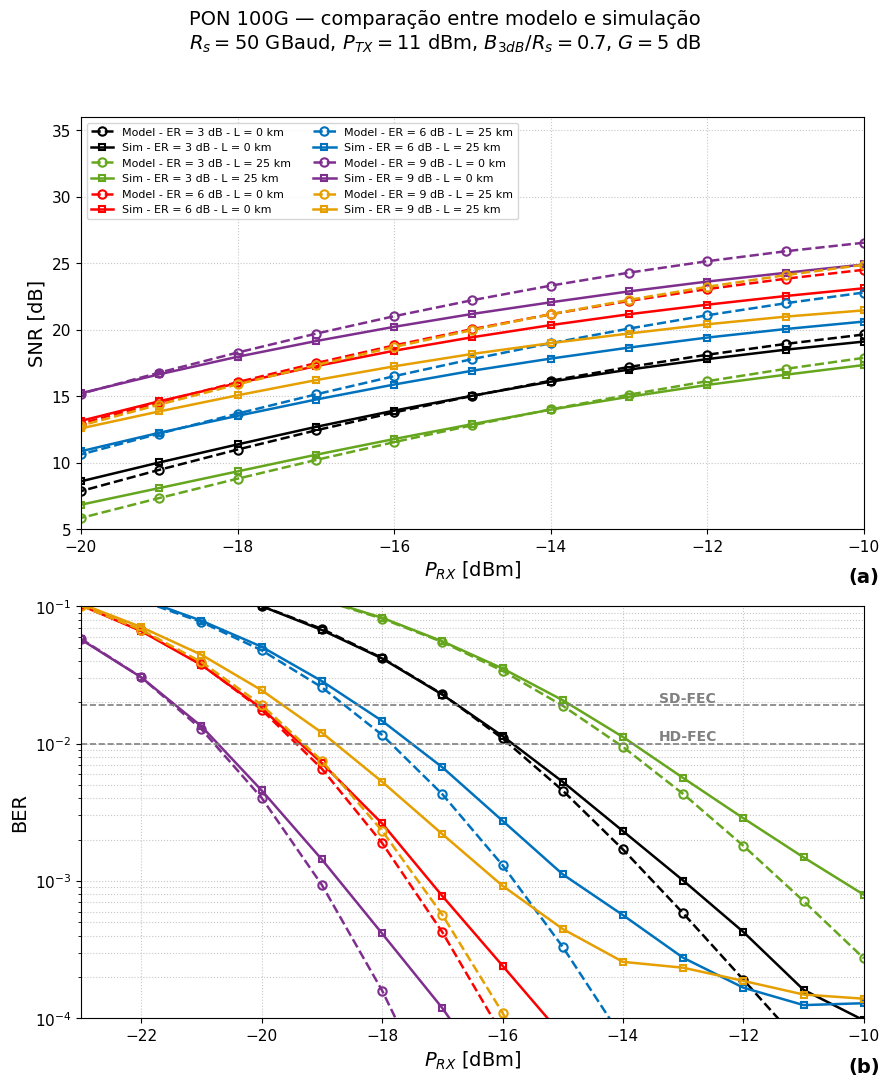

In [14]:



# =====================================================================
# 4. PARÂMETROS DA FIGURA 9
# =====================================================================

Rs = 50e9
M = 4
bits_per_symbol = int(np.log2(M))

SpS = 2
Fs = SpS * Rs

P_TX_dBm = 11.0
P_TX_W = 1e-3 * 10**(P_TX_dBm / 10)

received_power_dBm_values = np.arange(-23.0, -9.0, 1.0)
received_power_W_values = 1e-3 * 10**(received_power_dBm_values / 10)

extinction_ratios_dB = [3.0, 6.0, 9.0]
fiber_lengths_km = [0.0, 25.0]


# =====================================================================
# 5. APD, CANAL E RUÍDOS
# =====================================================================

APD_gain_dB = 5.0
APD_excess_factor_dB = 3.0

APD_gain = 10**(APD_gain_dB / 10)
APD_excess_factor = 10**(APD_excess_factor_dB / 10)

responsivity = 0.7
electron_charge = 1.602176634e-19

RIN_dB_Hz = -140.0
RIN_linear = 10**(RIN_dB_Hz / 10)

bandwidth_ratio = 0.7
bandwidth_3dB = bandwidth_ratio * Rs
supergaussian_order = 1

dispersion_coefficient = 3.85
wavelength = 1310e-9

# ---------------------------------------------------------------------
# PSD bilateral equivalente do ruído térmico no domínio de corrente.
#
# Esse é o parâmetro de conversão/calibração da convenção utilizada
# no artigo para a convenção elétrica deste código.
#
# Ele reproduz aproximadamente os níveis da Figura 9.
# ---------------------------------------------------------------------

N0_current = 1.0e-22


# =====================================================================
# 6. PARÂMETROS DA SIMULAÇÃO
# =====================================================================

# Para uma execução inicial mais rápida, use 200_000.
# Para a curva final próxima do artigo, use 500_000.
nBits = 500_000

seed_bits = 1234
seed_rin = 5000
seed_shot = 6000
seed_thermal = 7000

nTapsFFE = 200
mu_FFE = 5e-4
preconvergence_iterations = 1
guard_symbols = 1000


# =====================================================================
# 7. GERAÇÃO DOS SÍMBOLOS PAM-4
# =====================================================================

bit_parameters = parameters()
bit_parameters.nBits = nBits
bit_parameters.mode = "random"
bit_parameters.seed = seed_bits

transmitted_bits = bitSource(bit_parameters)
transmitted_bits = np.asarray(transmitted_bits, dtype=np.int64).reshape(-1)

number_valid_bits = (len(transmitted_bits) // bits_per_symbol) * bits_per_symbol
transmitted_bits = transmitted_bits[:number_valid_bits]

transmitted_symbols = modulateGray(transmitted_bits, M, "pam")
transmitted_symbols = np.real(np.asarray(transmitted_symbols)).reshape(-1)

# Símbolos físicos:
# [-3, -1, 1, 3]
reference_symbols = transmitted_symbols.copy()
normalized_symbols = transmitted_symbols / (M - 1)

number_symbols = len(reference_symbols)

# Pulso retangular NRZ com SpS amostras por símbolo
normalized_waveform = np.repeat(normalized_symbols, SpS)

number_samples = len(normalized_waveform)
simulation_frequencies = np.fft.fftfreq(number_samples, d=1 / Fs)


# =====================================================================
# 8. RESPOSTAS EM FREQUÊNCIA
# =====================================================================

simulation_bandwidth_response = superGauss(
    f=simulation_frequencies,
    n=supergaussian_order,
    B_3dB=bandwidth_3dB
)

maximum_analytical_frequency = 3e12
number_analytical_points = 120_001

analytical_frequencies = np.linspace(
    -maximum_analytical_frequency,
    maximum_analytical_frequency,
    number_analytical_points
)

symbol_period = 1 / Rs
transmitter_response = np.sinc(symbol_period * analytical_frequencies)

analytical_bandwidth_response = superGauss(
    f=analytical_frequencies,
    n=supergaussian_order,
    B_3dB=bandwidth_3dB
)


# =====================================================================
# 9. ESTRUTURAS DE RESULTADO
# =====================================================================

scenario_keys = [
    (extinction_ratio, fiber_length)
    for extinction_ratio in extinction_ratios_dB
    for fiber_length in fiber_lengths_km
]

SNR_model = {key: [] for key in scenario_keys}
BER_model = {key: [] for key in scenario_keys}
SNR_simulation = {key: [] for key in scenario_keys}
BER_simulation = {key: [] for key in scenario_keys}


# =====================================================================
# 10. MODELO ANALÍTICO
# =====================================================================

print("Calculando o modelo analítico...")

for extinction_ratio_dB in extinction_ratios_dB:
    for fiber_length_km in fiber_lengths_km:
        scenario = (extinction_ratio_dB, fiber_length_km)

        for received_power_W in received_power_W_values:
            snr_point, ber_point = calculate_analytical_point(
                received_power_W=received_power_W,
                extinction_ratio_dB=extinction_ratio_dB,
                fiber_length_km=fiber_length_km,
                analytical_frequencies=analytical_frequencies,
                transmitter_response=transmitter_response,
                bandwidth_response=analytical_bandwidth_response,
                dispersion_coefficient=dispersion_coefficient,
                wavelength=wavelength,
                symbol_rate=Rs,
                APD_gain=APD_gain,
                APD_excess_factor=APD_excess_factor,
                responsivity=responsivity,
                RIN_linear=RIN_linear,
                thermal_current_PSD=N0_current,
                electron_charge=electron_charge,
                M=M
            )

            SNR_model[scenario].append(snr_point)
            BER_model[scenario].append(ber_point)


# =====================================================================
# 11. SIMULAÇÃO TEMPORAL
# =====================================================================

print("Iniciando as simulações temporais.")
print(f"Símbolos: {number_symbols}")
print(f"Taps do FFE: {nTapsFFE}")
print()

for extinction_ratio_dB in extinction_ratios_dB:
    OMA_transmitted = calculate_oma_outer(P_TX_W, extinction_ratio_dB)

    transmitted_power = P_TX_W + (OMA_transmitted / 2) * normalized_waveform
    transmitted_power = np.maximum(transmitted_power, 0.0)

    # -------------------------------------------------------------
    # RIN na fonte, antes do canal e da fibra
    # -------------------------------------------------------------

    RIN_generator = np.random.default_rng(seed_rin + int(extinction_ratio_dB * 1000))
    RIN_variance = RIN_linear * transmitted_power**2 * Fs / 2

    RIN_noise = RIN_generator.normal(
        loc=0.0,
        scale=np.sqrt(np.maximum(RIN_variance, 0.0)),
        size=number_samples
    )

    transmitted_power_with_RIN = transmitted_power + RIN_noise
    transmitted_power_with_RIN = np.maximum(transmitted_power_with_RIN, 0.0)

    for fiber_length_km in fiber_lengths_km:
        scenario = (extinction_ratio_dB, fiber_length_km)

        print(f"\nER = {extinction_ratio_dB:.0f} dB | L = {fiber_length_km:.0f} km")

        # ---------------------------------------------------------
        # Propagação da dispersão no campo óptico
        # ---------------------------------------------------------

        optical_field_transmitted = np.sqrt(transmitted_power_with_RIN)

        field_dispersion_response = chromatic_dispersion_field_response(
            frequencies=simulation_frequencies,
            dispersion_ps_nm_km=dispersion_coefficient,
            length_km=fiber_length_km,
            wavelength_m=wavelength
        )

        optical_field_received = apply_frequency_response(
            signal=optical_field_transmitted,
            frequency_response=field_dispersion_response
        )

        optical_power_after_dispersion = np.abs(optical_field_received)**2

        # Normaliza apenas a forma de onda.
        # A potência média será definida por cada P_RX.
        optical_power_after_dispersion /= np.mean(optical_power_after_dispersion)

        # ---------------------------------------------------------
        # Limitação optoeletrônica de banda
        # ---------------------------------------------------------

        normalized_received_shape = np.real(
            apply_frequency_response(
                signal=optical_power_after_dispersion,
                frequency_response=simulation_bandwidth_response
            )
        )

        normalized_received_shape /= np.mean(normalized_received_shape)

        for power_index, (received_power_dBm, received_power_W) in enumerate(
            zip(received_power_dBm_values, received_power_W_values)
        ):
            # -----------------------------------------------------
            # Define a potência recebida média
            # -----------------------------------------------------

            instantaneous_received_power = received_power_W * normalized_received_shape
            power_for_shot = np.maximum(instantaneous_received_power, 0.0)

            # -----------------------------------------------------
            # Fotocorrente útil do APD
            #
            # i(t) = G*R*P_RX(t)
            # -----------------------------------------------------

            useful_photocurrent = APD_gain * responsivity * instantaneous_received_power

            # -----------------------------------------------------
            # Shot noise de avalanche
            #
            # sigma²(t)
            # = G²*F*q*R*P_RX(t)*Fs
            # -----------------------------------------------------

            shot_generator = np.random.default_rng(
                seed_shot
                + power_index
                + int(extinction_ratio_dB * 1000)
                + int(fiber_length_km * 100)
            )

            shot_variance = (
                APD_gain**2
                * APD_excess_factor
                * electron_charge
                * responsivity
                * power_for_shot
                * Fs
            )

            shot_noise = shot_generator.normal(
                loc=0.0,
                scale=np.sqrt(np.maximum(shot_variance, 0.0)),
                size=number_samples
            )

            # -----------------------------------------------------
            # Ruído térmico
            # -----------------------------------------------------

            thermal_generator = np.random.default_rng(
                seed_thermal
                + power_index
                + int(extinction_ratio_dB * 1000)
                + int(fiber_length_km * 100)
            )

            thermal_variance = N0_current * Fs / 2

            thermal_noise = thermal_generator.normal(
                loc=0.0,
                scale=np.sqrt(thermal_variance),
                size=number_samples
            )

            # -----------------------------------------------------
            # Entrada do FFE
            # -----------------------------------------------------

            received_current = useful_photocurrent + shot_noise + thermal_noise
            received_current_AC = received_current - np.mean(useful_photocurrent)

            equalizer_input = pnorm(received_current_AC)
            equalizer_input = np.real(np.asarray(equalizer_input)).reshape(-1)

            # -----------------------------------------------------
            # FFE em full-training
            # -----------------------------------------------------

            FFE_parameters = parameters()
            FFE_parameters.nTaps = nTapsFFE
            FFE_parameters.mu = mu_FFE
            FFE_parameters.SpS = SpS
            FFE_parameters.nTrain = number_symbols
            FFE_parameters.prec = np.float32
            FFE_parameters.M = M
            FFE_parameters.constType = "pam"
            FFE_parameters.f = None
            FFE_parameters.trainingMode = "data-aided"
            FFE_parameters.preconvIters = preconvergence_iterations

            FFE_result = ffe(equalizer_input, reference_symbols, FFE_parameters)
            equalized_output = FFE_result[0]

            simulation_snr_point, simulation_ber_point = evaluate_equalized_output(
                equalized_signal=equalized_output,
                reference_symbols=reference_symbols,
                guard_symbols=max(guard_symbols, nTapsFFE),
                M=M
            )

            SNR_simulation[scenario].append(simulation_snr_point)
            BER_simulation[scenario].append(simulation_ber_point)

            print(
                f"P_RX = {received_power_dBm:5.1f} dBm | "
                f"SNR modelo = {SNR_model[scenario][power_index]:6.2f} dB | "
                f"SNR sim = {simulation_snr_point:6.2f} dB | "
                f"BER modelo = {BER_model[scenario][power_index]:.3e} | "
                f"BER sim = {simulation_ber_point:.3e}"
            )

print("\nSimulações concluídas.")


# =====================================================================
# 12. ESTILOS DA FIGURA
# =====================================================================

scenario_colors = {
    (3.0, 0.0): "black",
    (3.0, 25.0): "#66A61E",
    (6.0, 0.0): "red",
    (6.0, 25.0): "#0072BD",
    (9.0, 0.0): "#7E2F8E",
    (9.0, 25.0): "#E69F00"
}


# =====================================================================
# 13. FIGURA 9
# =====================================================================

figure, (SNR_axis, BER_axis) = plt.subplots(2, 1, figsize=(9, 11))


# ---------------------------------------------------------------------
# 13.1 SNR
# ---------------------------------------------------------------------

for scenario in scenario_keys:
    extinction_ratio_dB, fiber_length_km = scenario
    color = scenario_colors[scenario]

    SNR_axis.plot(
        received_power_dBm_values,
        SNR_model[scenario],
        linestyle="--",
        marker="o",
        linewidth=1.8,
        markersize=6,
        markerfacecolor="none",
        markeredgewidth=1.5,
        color=color,
        label=(
            f"Model - ER = {extinction_ratio_dB:.0f} dB - "
            f"L = {fiber_length_km:.0f} km"
        )
    )

    SNR_axis.plot(
        received_power_dBm_values,
        SNR_simulation[scenario],
        linestyle="-",
        marker="s",
        linewidth=1.8,
        markersize=5,
        markerfacecolor="none",
        markeredgewidth=1.5,
        color=color,
        label=(
            f"Sim - ER = {extinction_ratio_dB:.0f} dB - "
            f"L = {fiber_length_km:.0f} km"
        )
    )

SNR_axis.set_xlim(-20, -10)
SNR_axis.set_ylim(5, 36)
SNR_axis.set_xlabel(r"$P_{RX}$ [dBm]", fontsize=14)
SNR_axis.set_ylabel("SNR [dB]", fontsize=14)
SNR_axis.grid(True, linestyle=":", alpha=0.7)
SNR_axis.legend(fontsize=8, ncol=2, loc="upper left")
SNR_axis.tick_params(axis="both", labelsize=11)

SNR_axis.text(
    1.02,
    -0.13,
    "(a)",
    transform=SNR_axis.transAxes,
    fontsize=14,
    fontweight="bold",
    horizontalalignment="right"
)


# ---------------------------------------------------------------------
# 13.2 BER
# ---------------------------------------------------------------------

for scenario in scenario_keys:
    color = scenario_colors[scenario]

    BER_axis.semilogy(
        received_power_dBm_values,
        BER_model[scenario],
        linestyle="--",
        marker="o",
        linewidth=1.8,
        markersize=6,
        markerfacecolor="none",
        markeredgewidth=1.5,
        color=color
    )

    BER_axis.semilogy(
        received_power_dBm_values,
        BER_simulation[scenario],
        linestyle="-",
        marker="s",
        linewidth=1.8,
        markersize=5,
        markerfacecolor="none",
        markeredgewidth=1.5,
        color=color
    )

# Limites de FEC
HD_FEC_threshold = 1e-2
SD_FEC_threshold = 1.9e-2

BER_axis.axhline(HD_FEC_threshold, linestyle="--", linewidth=1.2, color="gray")
BER_axis.axhline(SD_FEC_threshold, linestyle="--", linewidth=1.2, color="gray")

BER_axis.text(
    -13.4,
    HD_FEC_threshold * 1.05,
    "HD-FEC",
    fontsize=10,
    color="gray",
    fontweight="bold"
)

BER_axis.text(
    -13.4,
    SD_FEC_threshold * 1.05,
    "SD-FEC",
    fontsize=10,
    color="gray",
    fontweight="bold"
)

BER_axis.set_xlim(-23, -10)
BER_axis.set_ylim(1e-4, 1e-1)
BER_axis.set_xlabel(r"$P_{RX}$ [dBm]", fontsize=14)
BER_axis.set_ylabel("BER", fontsize=14)
BER_axis.grid(True, which="both", linestyle=":", alpha=0.7)
BER_axis.tick_params(axis="both", labelsize=11)

BER_axis.text(
    1.02,
    -0.13,
    "(b)",
    transform=BER_axis.transAxes,
    fontsize=14,
    fontweight="bold",
    horizontalalignment="right"
)


# ---------------------------------------------------------------------
# 13.3 Título e layout
# ---------------------------------------------------------------------

figure.suptitle(
    (
        "PON 100G — comparação entre modelo e simulação\n"
        rf"$R_s={Rs/1e9:.0f}$ GBaud, "
        rf"$P_{{TX}}={P_TX_dBm:.0f}$ dBm, "
        rf"$B_{{3dB}}/R_s={bandwidth_ratio:.1f}$, "
        rf"$G={APD_gain_dB:.0f}$ dB"
    ),
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Calculando as curvas da Figura 10...
Processando PAM2, 25G, FFE...
Processando PAM4, 25G, FFE...
Processando PAM4, 50G, FFE...
Processando PAM4, 50G, DFE...
Cálculo concluído.


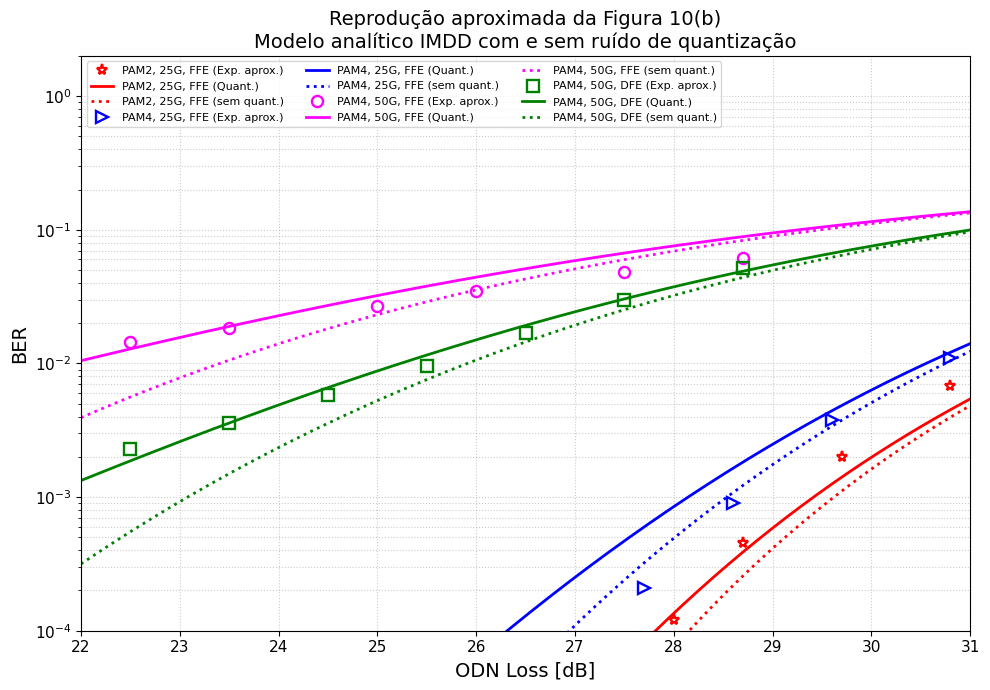

In [16]:
# REPRODUÇÃO APROXIMADA DA FIGURA 10(b)
#
# Comparação da BER em função da perda da ODN para:
#   - PAM2, 25G, FFE
#   - PAM4, 25G, FFE
#   - PAM4, 50G, FFE
#   - PAM4, 50G, DFE
#
# São apresentadas curvas com e sem ruído de quantização.
# 
# Funções auxiliares


# Parâmetros experimentais

P_TX_dBm = 11.5
P_TX_W = dbm_to_w(P_TX_dBm)

ER_dB = 5.0
OMA_TX = calculate_oma_outer(P_TX_W, ER_dB)

RIN_dB_Hz = -140.0
RIN_linear = 10**(RIN_dB_Hz / 10)

responsivity = 0.7
N0 = 2e-21

APD_gain_dB = 8.45
APD_gain = 10**(APD_gain_dB / 10)

APD_excess_factor_dB = 11.0
APD_excess_factor = 10**(APD_excess_factor_dB / 10)

accumulated_dispersion_ps_nm = -3.2
wavelength_m = 1310e-9

ENOB = 5
sampling_frequency = 100e9

system_filter_order = 2
system_bandwidth_3dB = 8.5e9

ADC_filter_order = 3
ADC_bandwidth_3dB = 33e9

ADC_LOADING_FACTOR = 32.0



# Configurações de modulação e equalização


configurations = {
    "PAM2_25G_FFE": {
        "bit_rate": 25e9,
        "M": 2,
        "equalizer": "FFE",
        "color": "red",
        "marker": "*",
        "description": "PAM2, 25G, FFE"
    },
    "PAM4_25G_FFE": {
        "bit_rate": 25e9,
        "M": 4,
        "equalizer": "FFE",
        "color": "blue",
        "marker": ">",
        "description": "PAM4, 25G, FFE"
    },
    "PAM4_50G_FFE": {
        "bit_rate": 50e9,
        "M": 4,
        "equalizer": "FFE",
        "color": "magenta",
        "marker": "o",
        "description": "PAM4, 50G, FFE"
    },
    "PAM4_50G_DFE": {
        "bit_rate": 50e9,
        "M": 4,
        "equalizer": "DFE",
        "color": "green",
        "marker": "s",
        "description": "PAM4, 50G, DFE"
    }
}



# Eixo de perda e grade de frequência

ODN_loss_dB = np.linspace(22.0, 31.0, 181)

frequency_step = 25e6
frequencies = np.arange(-100e9, 100e9 + frequency_step, frequency_step)

ADC_Nyquist_mask = np.abs(frequencies) <= sampling_frequency / 2


# Respostas em frequência fixas


H_system = superGauss(frequencies, system_filter_order, system_bandwidth_3dB)

H_CD = chromatic_dispersion_small_signal(
    frequencies,
    accumulated_dispersion_ps_nm,
    wavelength_m
)

H_ADC = superGauss(frequencies, ADC_filter_order, ADC_bandwidth_3dB)

H_fixed = H_system * H_CD * H_ADC


# Cálculo da curva de BER

def calculate_ber_curve(configuration, include_quantization):
    """Calcula a curva de BER para uma configuração do sistema."""

    bit_rate = configuration["bit_rate"]
    M = configuration["M"]
    equalizer_type = configuration["equalizer"]

    bits_per_symbol = np.log2(M)
    symbol_rate = bit_rate / bits_per_symbol
    symbol_period = 1 / symbol_rate

    levels = pam_levels(M)
    symbol_variance = np.mean(levels**2)

    signal_coefficient = symbol_period * OMA_TX**2 * symbol_variance / (4 * (M - 1)**2)

    H_TX = np.sinc(symbol_period * frequencies)

    transmitted_power_levels = P_TX_W + (OMA_TX / (2 * (M - 1))) * levels

    PAPR = np.max(levels**2) / symbol_variance

    BER_curve = []

    for loss_dB in ODN_loss_dB:

        optical_transmission = 10**(-loss_dB / 10)
        P_RX_W = P_TX_W * optical_transmission

        H_channel = APD_gain * optical_transmission * H_fixed
        H_channel_squared = np.abs(H_channel)**2

        signal_PSD = signal_coefficient * np.abs(H_TX)**2 * H_channel_squared

        sigma_x_squared = np.trapezoid(
            signal_PSD[ADC_Nyquist_mask],
            x=frequencies[ADC_Nyquist_mask]
        )

        if include_quantization:
            S_ADC = ADC_LOADING_FACTOR * PAPR * sigma_x_squared / (
                12 * sampling_frequency * 2**(2 * ENOB - 2)
            )
        else:
            S_ADC = 0.0

        eye_BER_values = []

        for eye_index in range(M - 1):

            eye_levels_TX = transmitted_power_levels[eye_index:eye_index + 2]

            mean_square_power_TX_eye = np.mean(eye_levels_TX**2)
            mean_power_TX_eye = np.mean(eye_levels_TX)
            mean_power_RX_eye = mean_power_TX_eye * optical_transmission

            S_RIN = RIN_linear * mean_square_power_TX_eye * H_channel_squared / 2

            S_shot = (
                APD_gain**2
                * APD_excess_factor
                * electron_charge
                * mean_power_RX_eye
                / responsivity
            )

            S_thermal = N0 / 2

            total_noise_PSD = S_RIN + S_shot + S_thermal + S_ADC

            spectral_snr = np.zeros_like(frequencies)

            spectral_snr[ADC_Nyquist_mask] = (
                signal_PSD[ADC_Nyquist_mask]
                / np.maximum(total_noise_PSD[ADC_Nyquist_mask], np.finfo(float).tiny)
            )

            folded_snr = fold_snr_uniform_grid(
                spectral_snr,
                frequency_step,
                symbol_rate,
                sampling_frequency
            )

            output_snr = equalizer_output_snr(
                frequencies,
                folded_snr,
                symbol_rate,
                equalizer_type
            )

            eye_BER = ber_from_snr_m_pam(output_snr, M)
            eye_BER_values.append(float(eye_BER))

        BER_curve.append(np.mean(eye_BER_values))

    return np.asarray(BER_curve)



# Cálculo das curvas


BER_with_quantization = {}
BER_without_quantization = {}

print("Calculando as curvas da Figura 10...")

for configuration_name, configuration in configurations.items():

    print(f"Processando {configuration['description']}...")

    BER_with_quantization[configuration_name] = calculate_ber_curve(
        configuration,
        include_quantization=True
    )

    BER_without_quantization[configuration_name] = calculate_ber_curve(
        configuration,
        include_quantization=False
    )

print("Cálculo concluído.")



# Dados experimentais aproximados


experimental_data = {
    "PAM2_25G_FFE": {
        "x": np.array([28.0, 28.7, 29.7, 30.8]),
        "y": np.array([1.2e-4, 4.5e-4, 2.0e-3, 6.8e-3])
    },
    "PAM4_25G_FFE": {
        "x": np.array([26.7, 27.7, 28.6, 29.6, 30.8]),
        "y": np.array([3.5e-5, 2.1e-4, 9.0e-4, 3.8e-3, 1.1e-2])
    },
    "PAM4_50G_FFE": {
        "x": np.array([22.5, 23.5, 25.0, 26.0, 27.5, 28.7]),
        "y": np.array([1.45e-2, 1.85e-2, 2.7e-2, 3.5e-2, 4.8e-2, 6.2e-2])
    },
    "PAM4_50G_DFE": {
        "x": np.array([22.5, 23.5, 24.5, 25.5, 26.5, 27.5, 28.7]),
        "y": np.array([2.3e-3, 3.6e-3, 5.8e-3, 9.5e-3, 1.7e-2, 3.0e-2, 5.2e-2])
    }
}

# Gráfico


plt.figure(figsize=(10, 7))

legend_handles = []
legend_labels = []

for configuration_name, configuration in configurations.items():

    color = configuration["color"]
    marker = configuration["marker"]
    description = configuration["description"]

    experimental_line, = plt.plot(
        experimental_data[configuration_name]["x"],
        experimental_data[configuration_name]["y"],
        linestyle="none",
        marker=marker,
        markersize=8,
        markerfacecolor="none",
        markeredgewidth=1.7,
        color=color
    )

    legend_handles.append(experimental_line)
    legend_labels.append(f"{description} (Exp. aprox.)")

    quantization_line, = plt.semilogy(
        ODN_loss_dB,
        BER_with_quantization[configuration_name],
        linestyle="-",
        linewidth=2.0,
        color=color
    )

    legend_handles.append(quantization_line)
    legend_labels.append(f"{description} (Quant.)")

    no_quantization_line, = plt.semilogy(
        ODN_loss_dB,
        BER_without_quantization[configuration_name],
        linestyle=":",
        linewidth=2.0,
        color=color
    )

    legend_handles.append(no_quantization_line)
    legend_labels.append(f"{description} (sem quant.)")


plt.xlabel("ODN Loss [dB]", fontsize=14)
plt.ylabel("BER", fontsize=14)

plt.title(
    "Reprodução aproximada da Figura 10(b)\n"
    "Modelo analítico IMDD com e sem ruído de quantização",
    fontsize=14
)

plt.xlim(22, 31)
plt.ylim(1e-4, 2)

plt.xticks(np.arange(22, 32, 1))

plt.grid(True, which="both", linestyle=":", alpha=0.65)

plt.legend(
    legend_handles,
    legend_labels,
    fontsize=8,
    ncol=3,
    loc="upper left"
)

plt.tick_params(axis="both", labelsize=11)

plt.tight_layout()
plt.show()